In [6]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
for f in os.listdir("."):
    print(f)

Current working directory:
/content

Files in current directory:
.config
sample_data


In [14]:
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_roi_timeseries_z.csv to sub-PC001_ses-01_task-rest_run-1_roi_timeseries_z.csv


In [16]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

roi_path = "/content/sub-PC001_ses-01_task-rest_run-1_roi_timeseries_z.csv"
df = pd.read_csv(roi_path)

print("Raw shape:", df.shape)
print(df.head())

arr = df.values

# 如果有非數值欄位，改用只取數值欄位
arr = df.select_dtypes(include=[np.number]).values

print("Numeric array shape:", arr.shape)

# 確保 time x roi
if arr.shape[0] == 504 and arr.shape[1] == 67:
    ts = arr
elif arr.shape[0] == 67 and arr.shape[1] == 504:
    ts = arr.T
else:
    print("Unexpected shape:", arr.shape)
    raise ValueError("Expected shape (504,67) or (67,504).")

# 對每個 ROI 沿時間軸做 z-score
ts_z = zscore(ts, axis=0, nan_policy="omit")
ts_z = np.nan_to_num(ts_z)

print("Z-scored shape:", ts_z.shape)


Raw shape: (504, 67)
    ROI_001   ROI_002   ROI_003   ROI_004   ROI_005   ROI_006   ROI_007  \
0  0.871896  1.847946  1.211163  1.819440  2.652066  2.198247  2.748463   
1  0.122011  1.219951  1.139313  0.869339  1.941109  1.648859  2.182163   
2  0.199009  1.127419  0.883281  0.828267  1.699051  1.086986  2.074323   
3 -0.123406  1.063996  0.847440  0.880835  1.377044  1.432301  1.865776   
4  0.326947  1.419887  1.230892  0.871844  1.072888  1.478730  1.828950   

    ROI_008   ROI_009   ROI_010  ...   ROI_058   ROI_059   ROI_060   ROI_061  \
0 -0.443988 -0.579493  1.522887  ...  3.213022  0.860738  2.889266  2.581675   
1 -0.562737 -1.131719  0.322810  ...  2.244077  1.100323  2.229214  2.156177   
2 -1.220911 -1.150560 -0.271205  ...  2.037248  1.032012  1.924950  1.896628   
3 -1.076732 -1.297578 -0.355761  ...  2.090259  0.914008  1.799845  2.072862   
4 -1.128111 -1.082626 -0.568551  ...  1.843558  1.218476  1.892124  1.845417   

    ROI_062   ROI_063   ROI_064   ROI_065   ROI

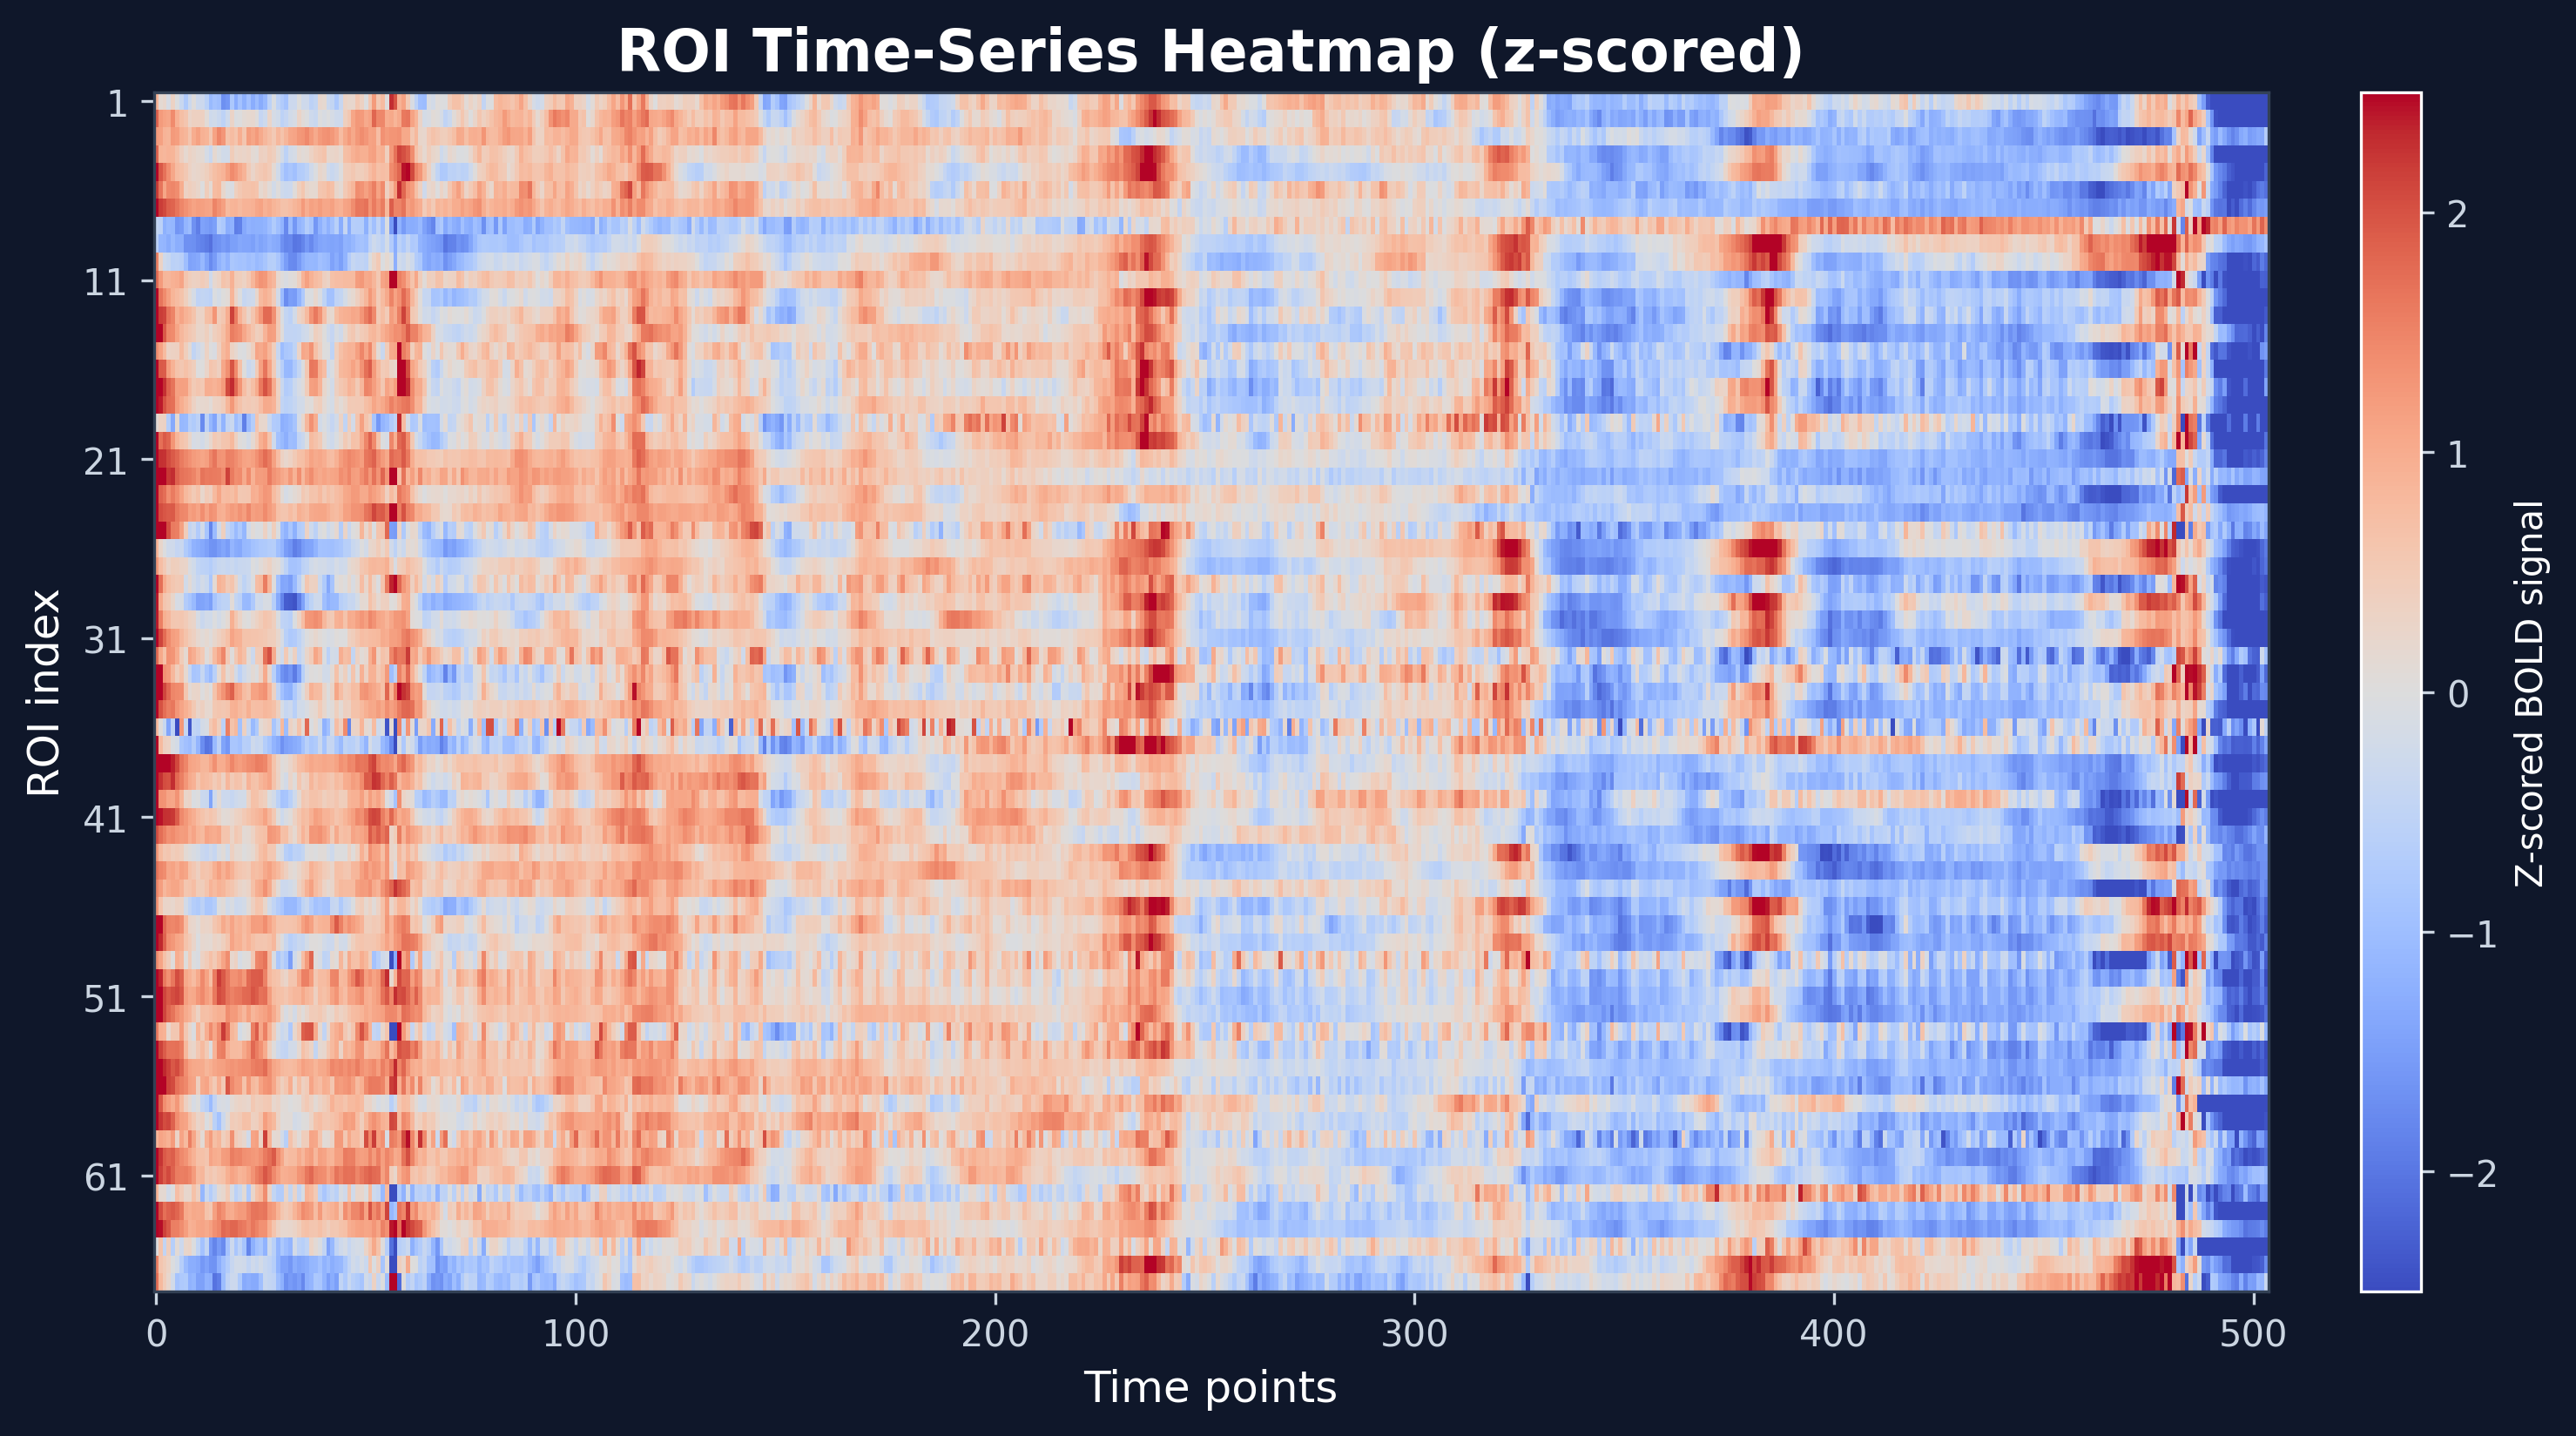

Saved: /content/roi_timeseries_heatmap_dark.png


In [17]:
# === 4) plot heatmap ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 5.6), dpi=300)

im = ax.imshow(
    ts_z.T,
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
    vmin=-2.5,
    vmax=2.5
)

ax.set_title("ROI Time-Series Heatmap (z-scored)", fontsize=16, weight="bold", color="white")
ax.set_xlabel("Time points", fontsize=12, color="white")
ax.set_ylabel("ROI index", fontsize=12, color="white")

ax.set_yticks(np.arange(0, ts_z.shape[1], 10))
ax.set_yticklabels(np.arange(1, ts_z.shape[1] + 1, 10))
ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Z-scored BOLD signal", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")
for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/roi_timeseries_heatmap_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

In [18]:
from pathlib import Path

for p in Path(".").rglob("*"):
    name = p.name.lower()
    if any(k in name for k in ["participants", "sessions", "scans", "events", "phenotype", "readme", "dataset"]):
        print(p)

sample_data/README.md


In [20]:
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_static_fc.csv to sub-PC001_ses-01_task-rest_run-1_static_fc.csv


FC shape: (67, 67)
min: -0.8532714023420677 max: 1.0
diagonal mean: 1.0


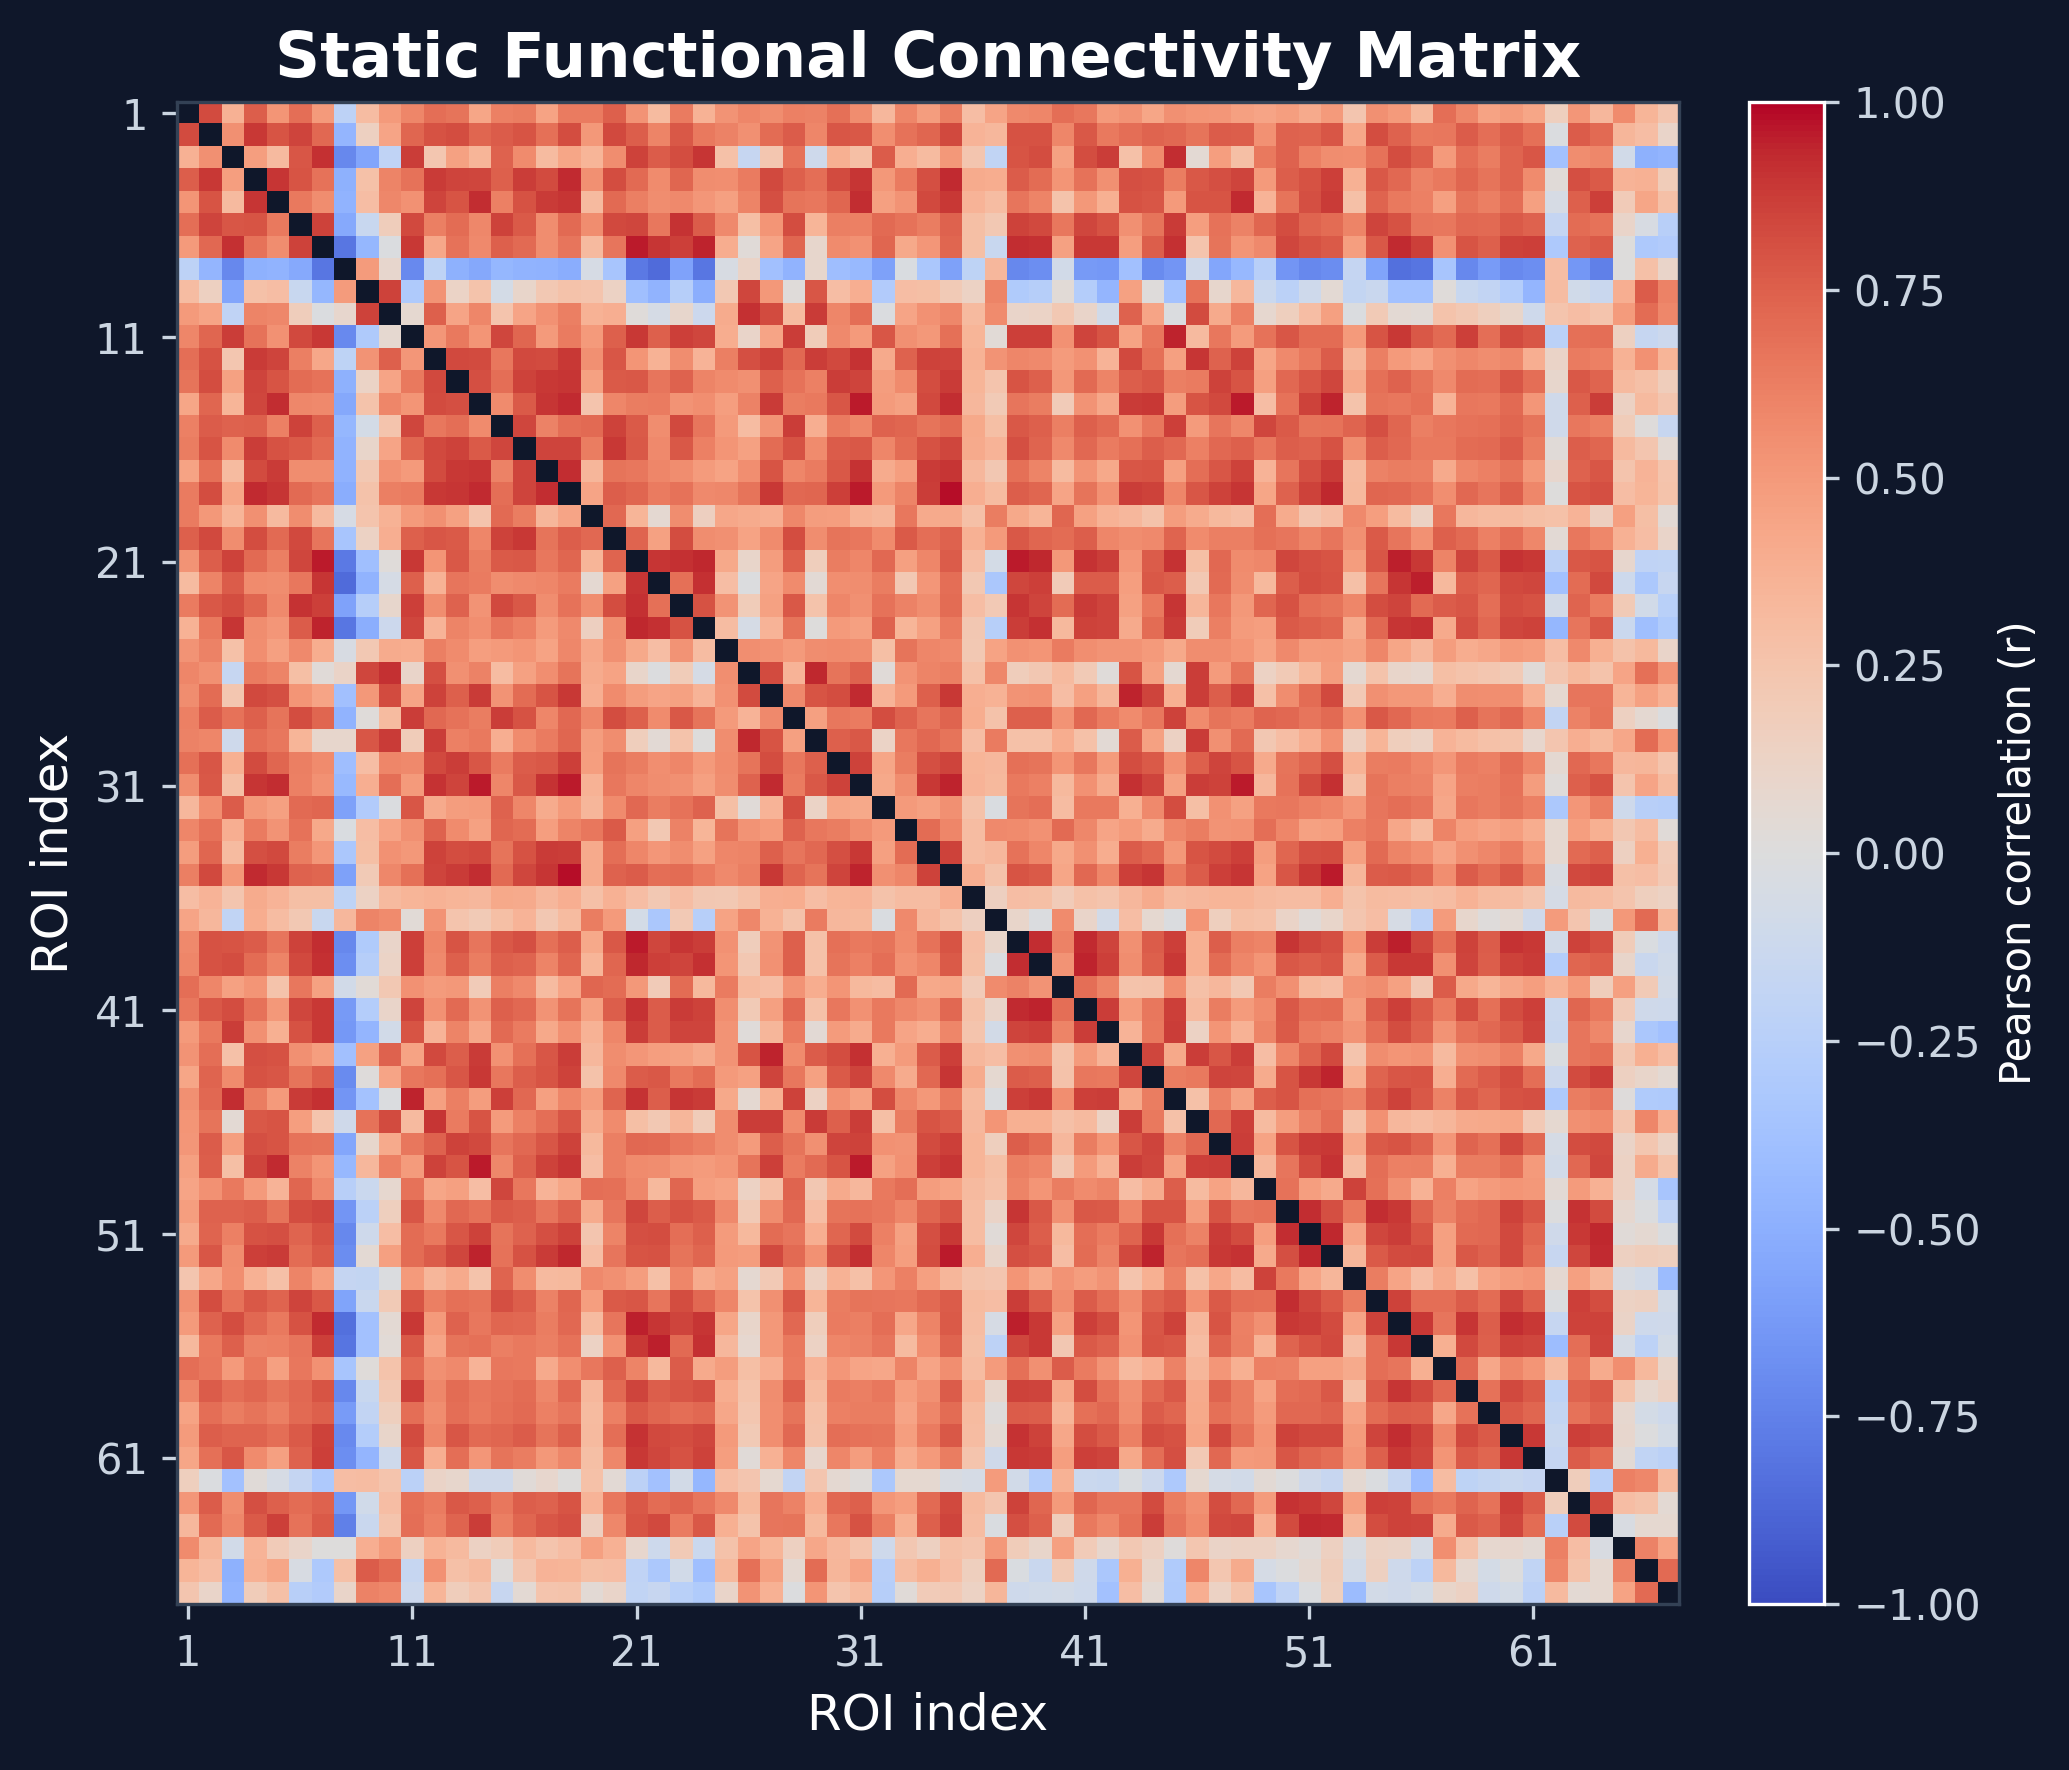

Saved: /content/static_fc_heatmap_dark.png


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1) load static FC matrix ===
fc_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc.csv"

fc_df = pd.read_csv(fc_path, index_col=0)
fc = fc_df.values.astype(float)

print("FC shape:", fc.shape)
print("min:", np.nanmin(fc), "max:", np.nanmax(fc))
print("diagonal mean:", np.mean(np.diag(fc)))

# === 2) mask diagonal for visualization ===
fc_plot = fc.copy()
np.fill_diagonal(fc_plot, np.nan)

# === 3) plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

im = ax.imshow(
    fc_plot,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

ax.set_title("Static Functional Connectivity Matrix", fontsize=15, weight="bold", color="white")
ax.set_xlabel("ROI index", fontsize=12, color="white")
ax.set_ylabel("ROI index", fontsize=12, color="white")

# ticks
n_roi = fc.shape[0]
tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.tick_params(colors="#cbd5e1")

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation (r)", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/static_fc_heatmap_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

In [23]:
from google.colab import files
uploaded = files.upload()

Saving sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv to sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv


Fisher-z FC shape: (67, 67)
min: -1.26806153806909 max: 7.254328619247669
diagonal mean: 7.25432861924767
Color range: -1.5452751611364623 1.5452751611364623


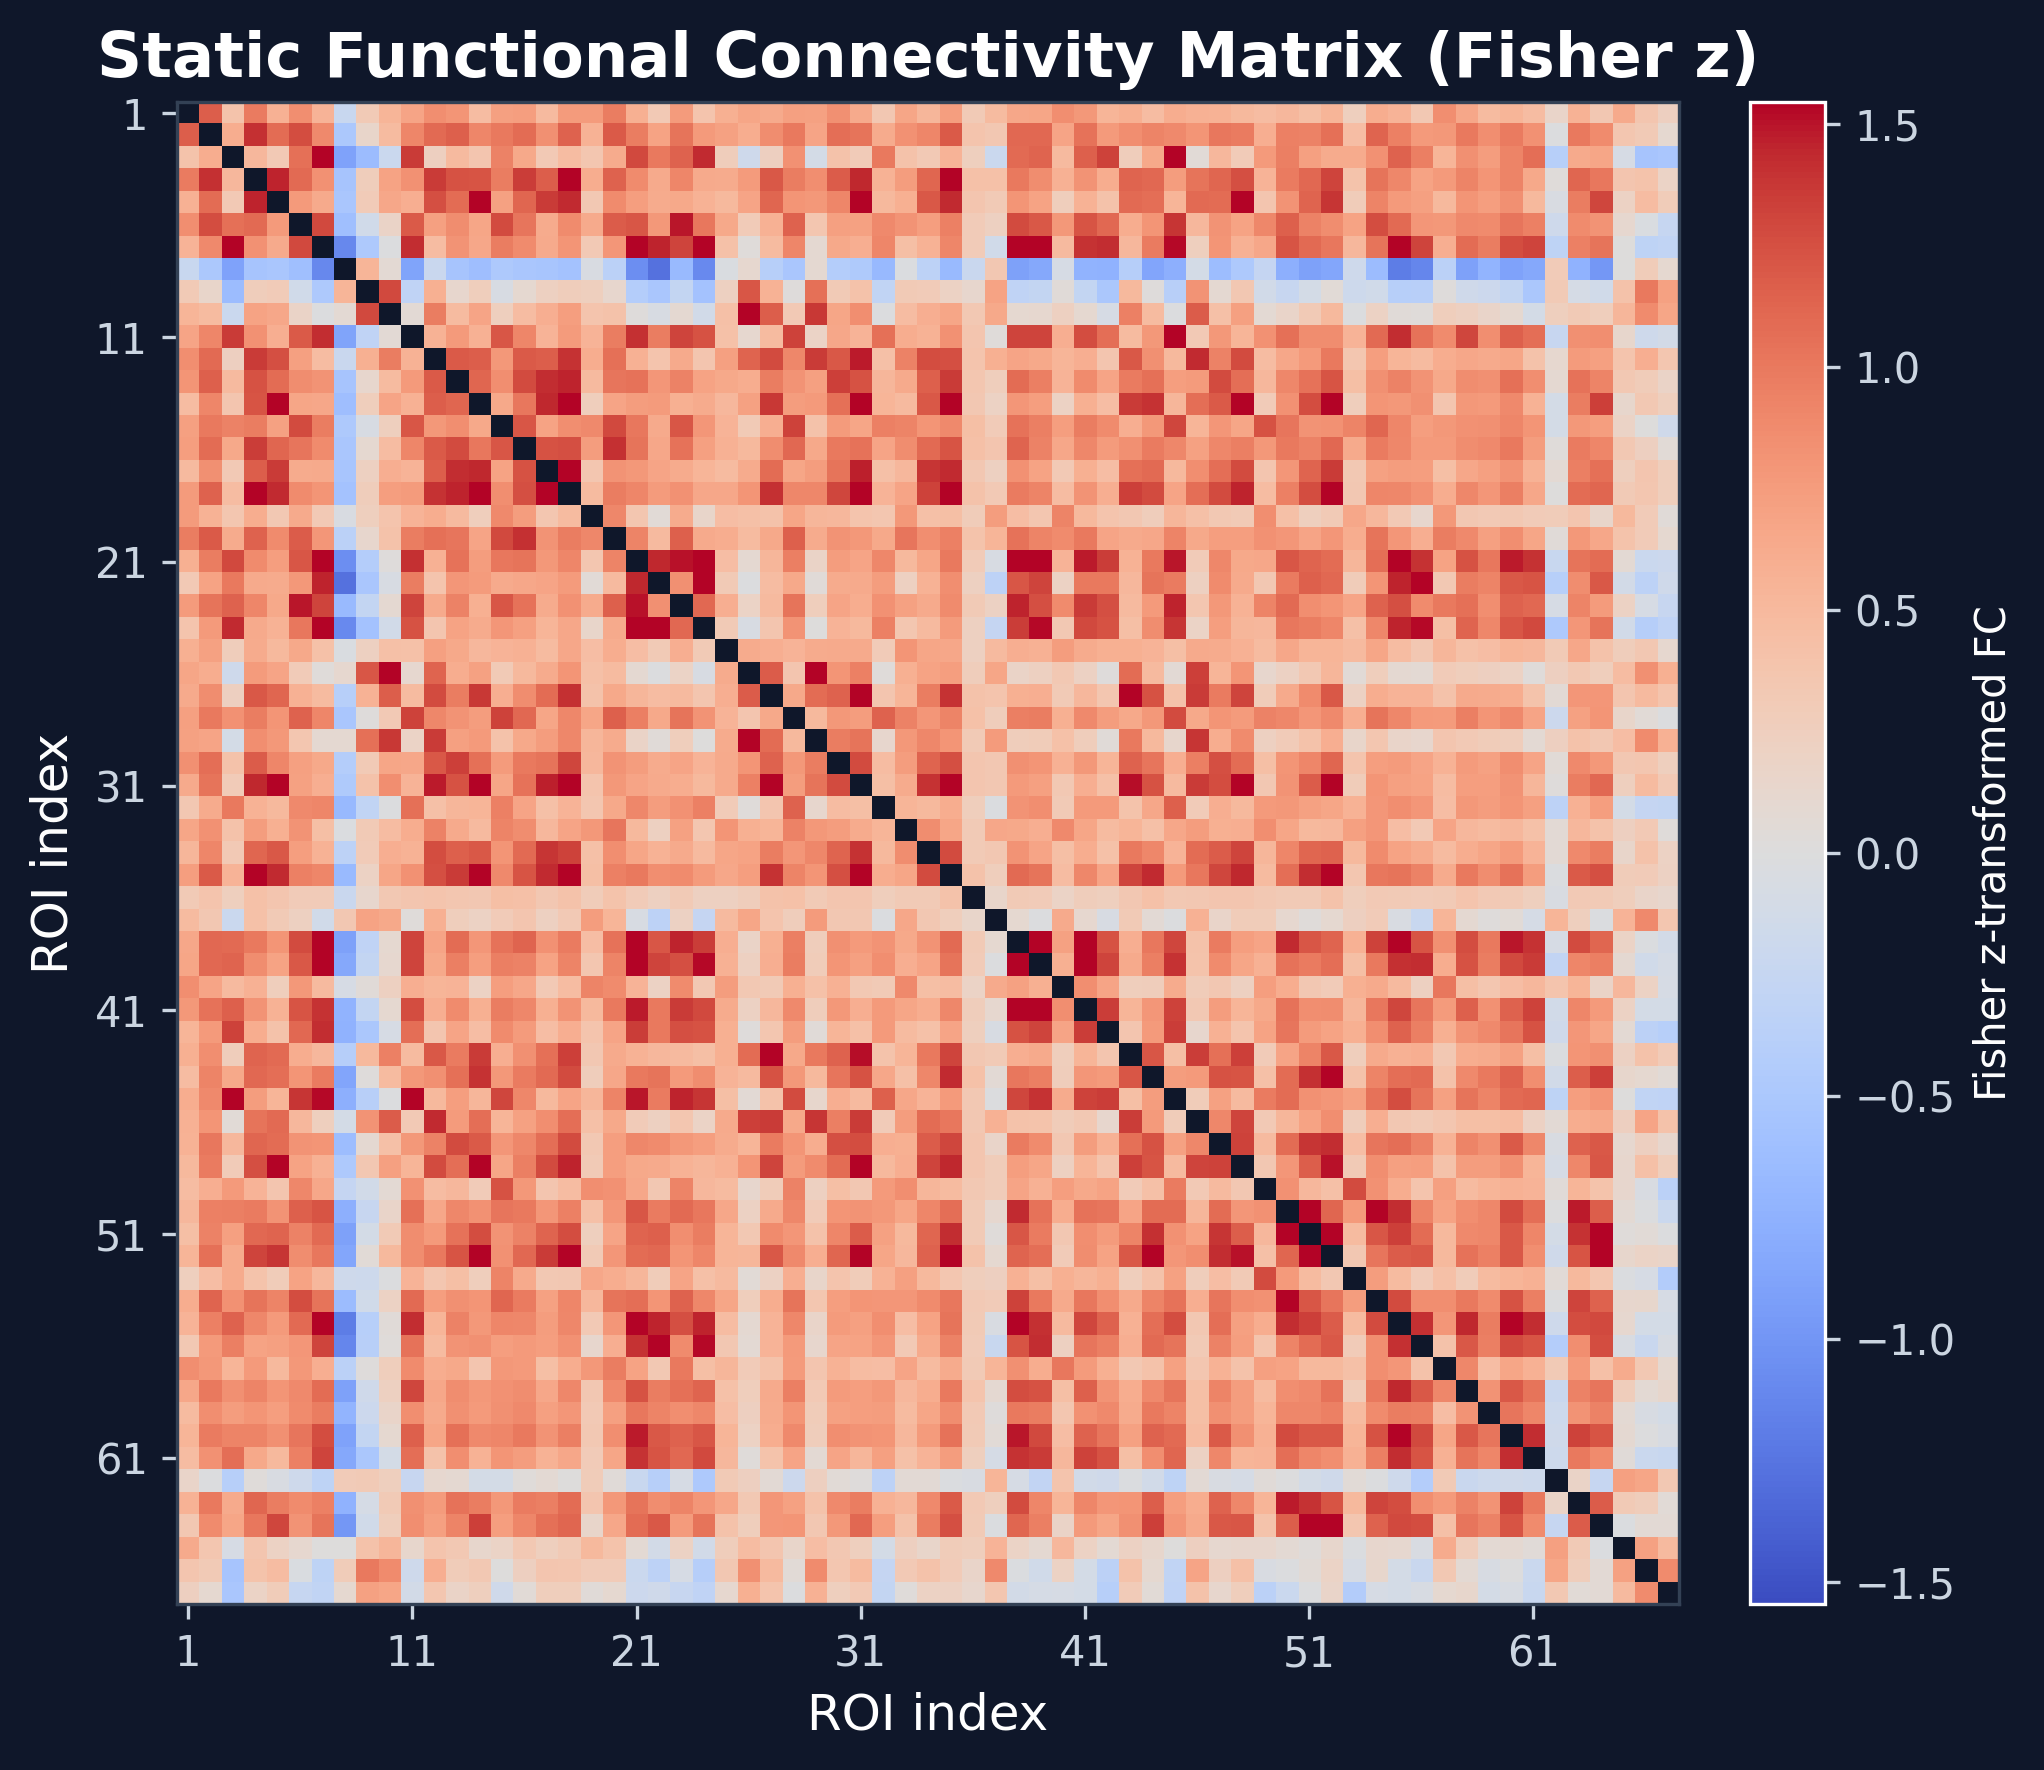

Saved: /content/static_fc_fisher_z_heatmap_dark.png
Fisher-z FC shape: (67, 67)
min: -1.26806153806909 max: 7.254328619247669
diagonal mean: 7.25432861924767
Color range: -1.5452751611364623 1.5452751611364623


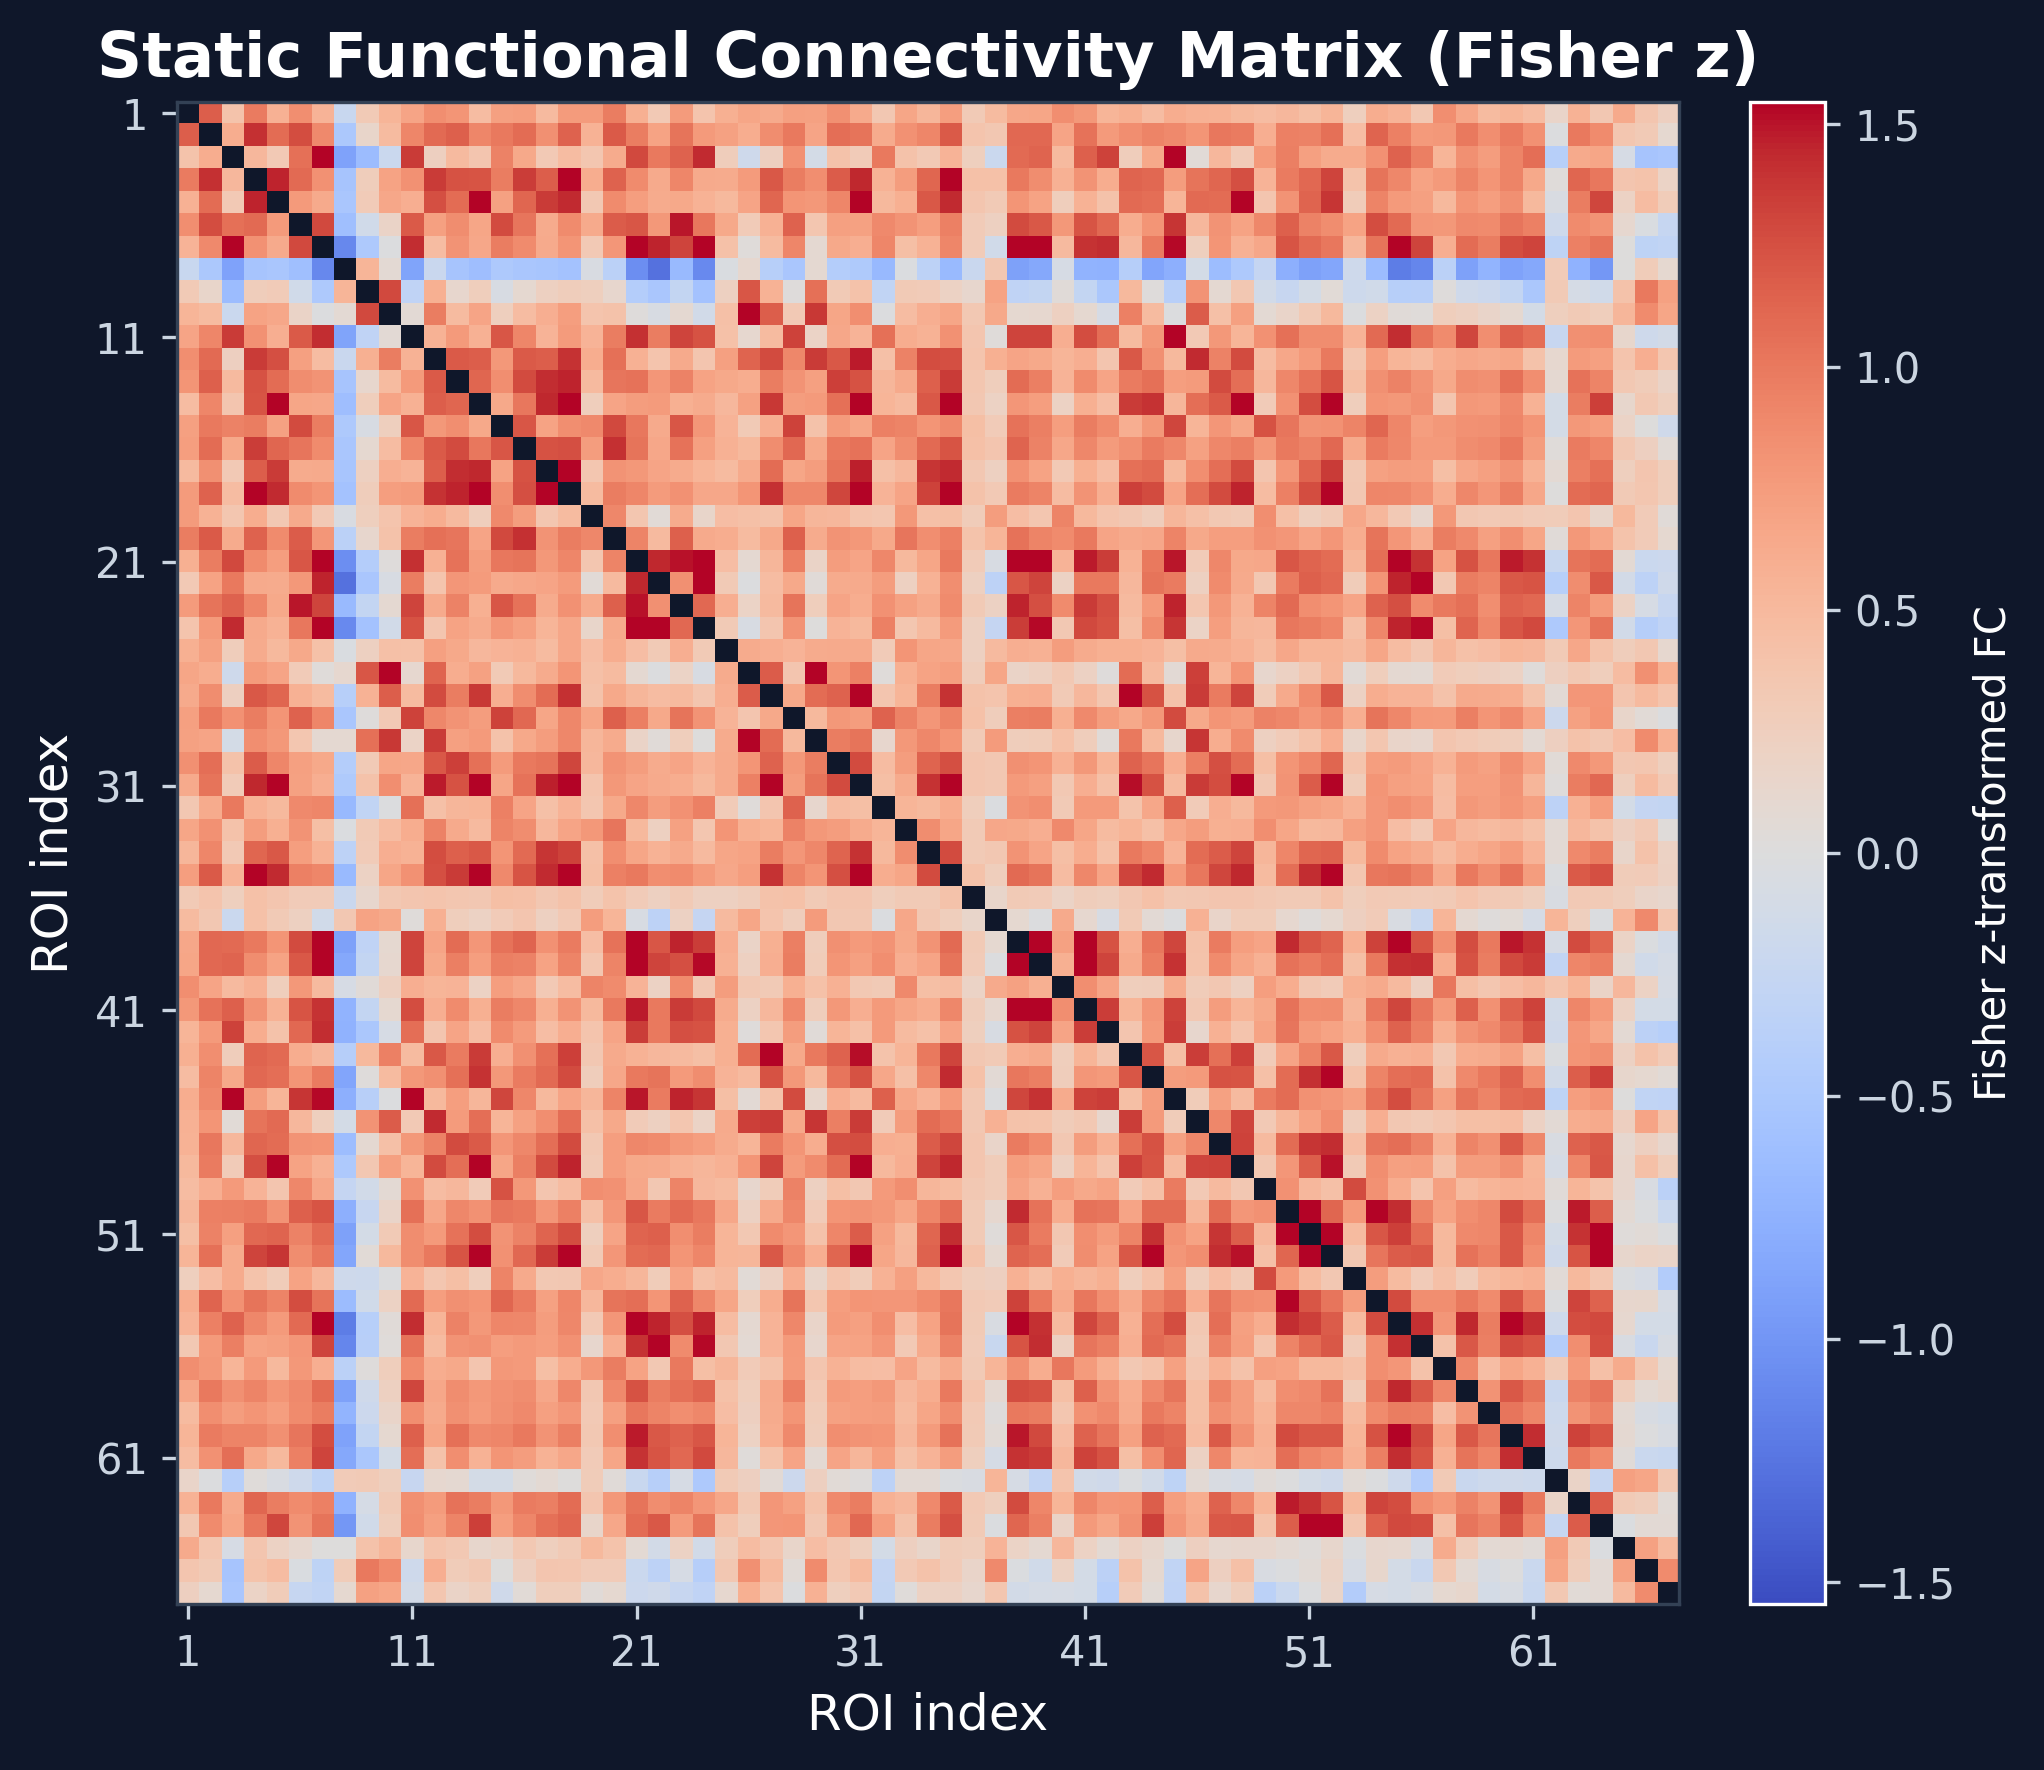

Saved: /content/static_fc_fisher_z_heatmap_dark.png


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1) load Fisher-z static FC matrix ===
fc_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv"

fc_df = pd.read_csv(fc_path, index_col=0)
fc_z = fc_df.values.astype(float)

print("Fisher-z FC shape:", fc_z.shape)
print("min:", np.nanmin(fc_z), "max:", np.nanmax(fc_z))
print("diagonal mean:", np.mean(np.diag(fc_z)))

# === 2) mask diagonal ===
fc_plot = fc_z.copy()
np.fill_diagonal(fc_plot, np.nan)

# === 3) robust color range ===
vmax = np.nanpercentile(np.abs(fc_plot), 98)
vmin = -vmax

print("Color range:", vmin, vmax)

# === 4) plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

im = ax.imshow(
    fc_plot,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

ax.set_title("Static Functional Connectivity Matrix (Fisher z)", fontsize=15, weight="bold", color="white")
ax.set_xlabel("ROI index", fontsize=12, color="white")
ax.set_ylabel("ROI index", fontsize=12, color="white")

n_roi = fc_z.shape[0]
tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Fisher z-transformed FC", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/static_fc_fisher_z_heatmap_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1) load Fisher-z static FC matrix ===
fc_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc_fisher_z.csv"

fc_df = pd.read_csv(fc_path, index_col=0)
fc_z = fc_df.values.astype(float)

print("Fisher-z FC shape:", fc_z.shape)
print("min:", np.nanmin(fc_z), "max:", np.nanmax(fc_z))
print("diagonal mean:", np.mean(np.diag(fc_z)))

# === 2) mask diagonal ===
fc_plot = fc_z.copy()
np.fill_diagonal(fc_plot, np.nan)

# === 3) robust color range ===
vmax = np.nanpercentile(np.abs(fc_plot), 98)
vmin = -vmax

print("Color range:", vmin, vmax)

# === 4) plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

im = ax.imshow(
    fc_plot,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)

ax.set_title("Static Functional Connectivity Matrix (Fisher z)", fontsize=15, weight="bold", color="white")
ax.set_xlabel("ROI index", fontsize=12, color="white")
ax.set_ylabel("ROI index", fontsize=12, color="white")

n_roi = fc_z.shape[0]
tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Fisher z-transformed FC", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/static_fc_fisher_z_heatmap_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


Number of edges: 2211
Mean FC: 0.4955268310482331
Median FC: 0.5771553649531224
SD FC: 0.3339049517155171
Min FC: -0.8532714023420677
Max FC: 0.9828635709382086
Proportion positive: 0.9081863410221619
Proportion negative: 0.09181365897783808


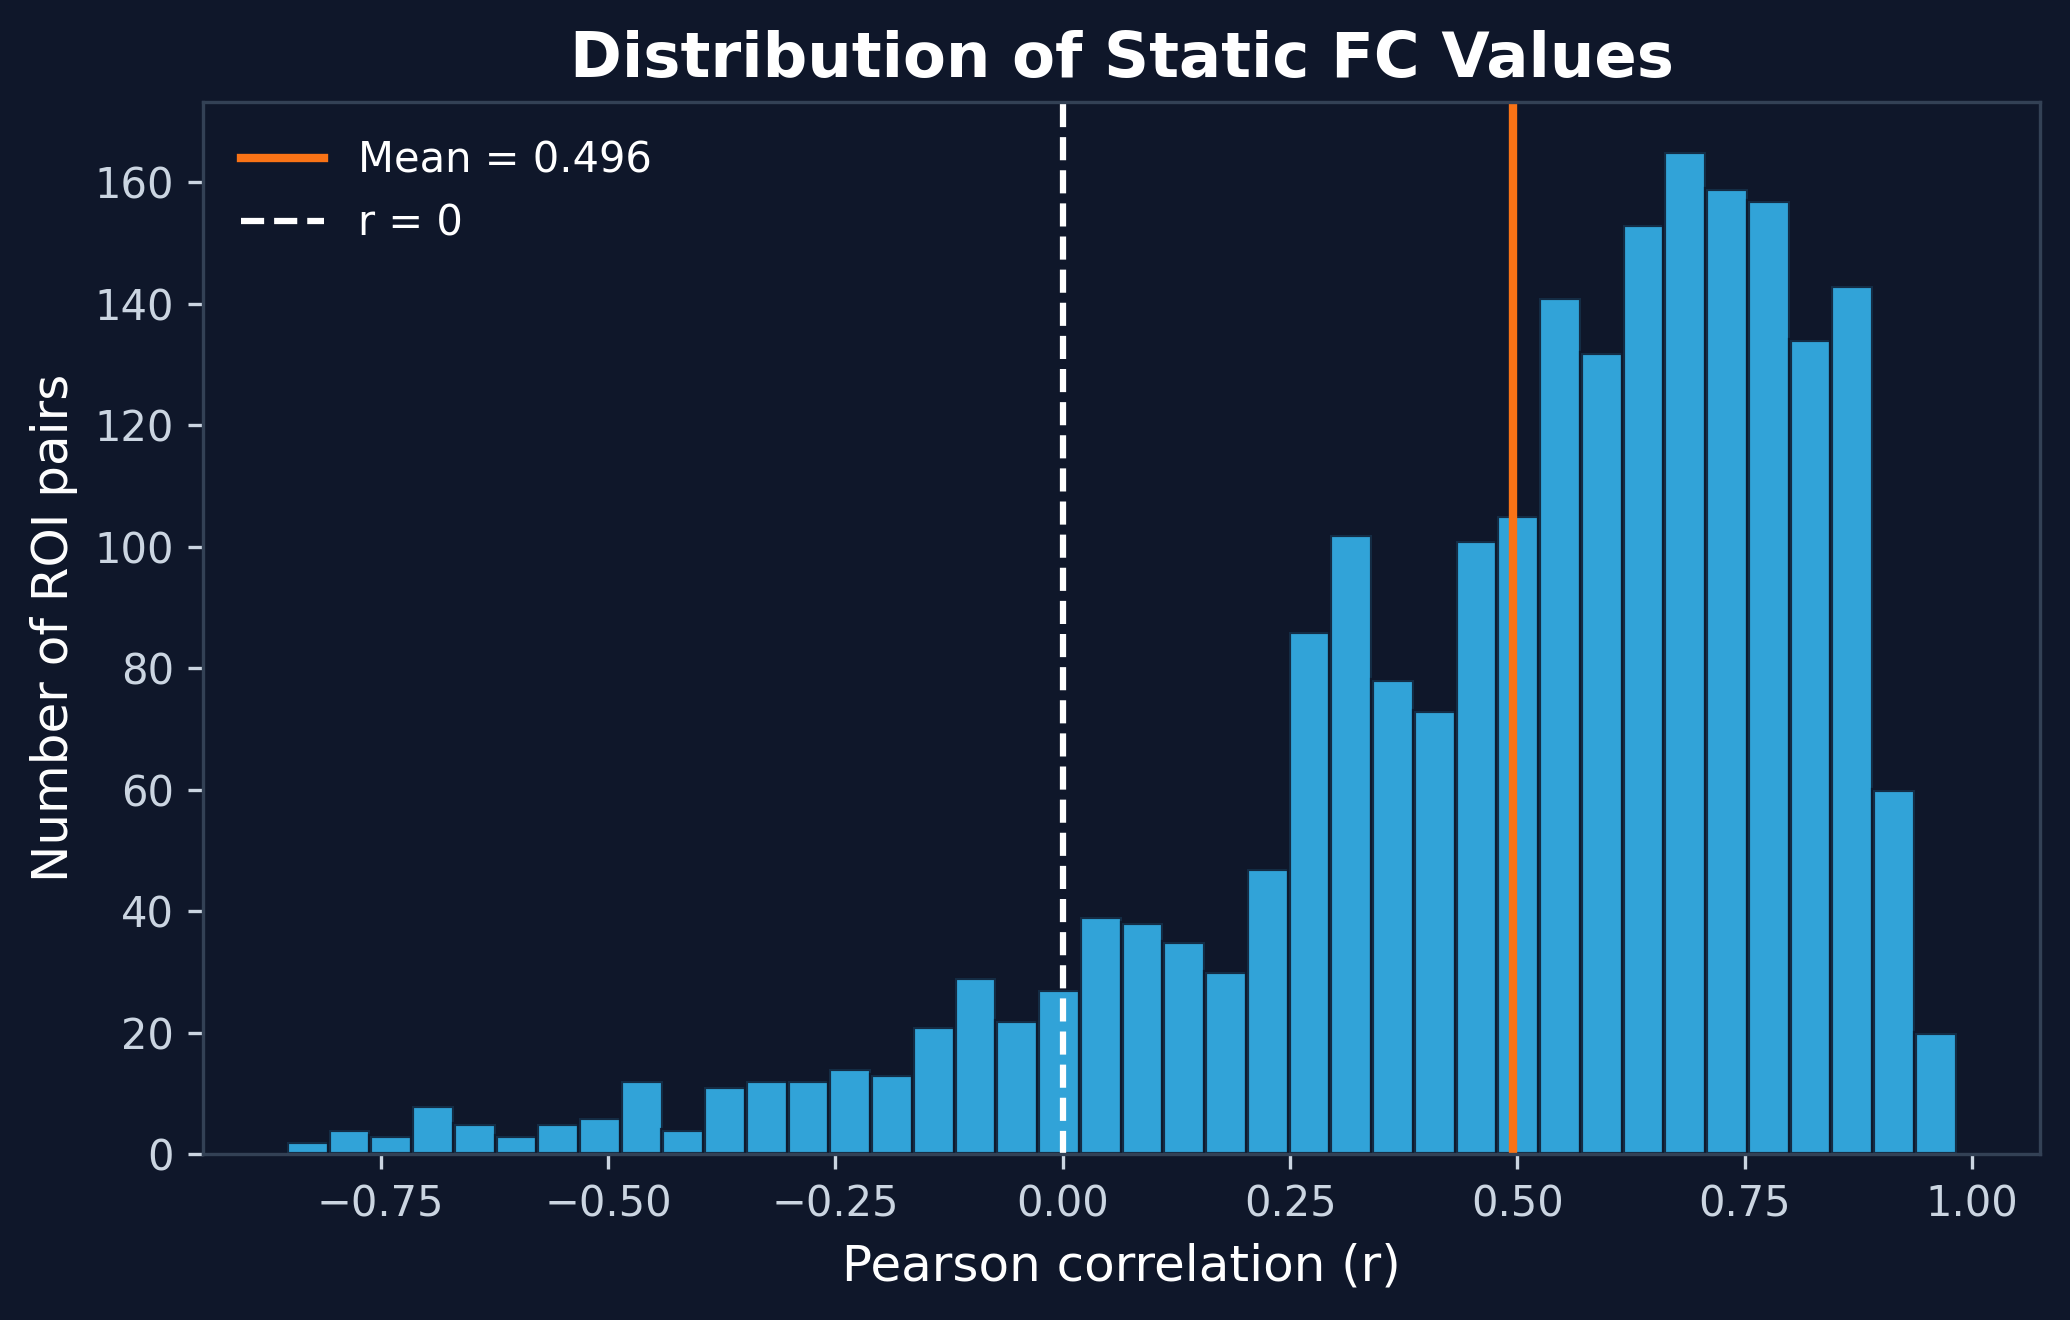

Saved: /content/static_fc_distribution_dark.png


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === load static FC ===
fc_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc.csv"
fc_df = pd.read_csv(fc_path, index_col=0)
fc = fc_df.values.astype(float)

# === extract upper triangle, excluding diagonal ===
n = fc.shape[0]
upper_idx = np.triu_indices(n, k=1)
edges = fc[upper_idx]

print("Number of edges:", len(edges))
print("Mean FC:", np.mean(edges))
print("Median FC:", np.median(edges))
print("SD FC:", np.std(edges))
print("Min FC:", np.min(edges))
print("Max FC:", np.max(edges))
print("Proportion positive:", np.mean(edges > 0))
print("Proportion negative:", np.mean(edges < 0))

# === plot histogram ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

ax.hist(
    edges,
    bins=40,
    color="#38bdf8",
    alpha=0.85,
    edgecolor="#0f172a"
)

ax.axvline(np.mean(edges), color="#f97316", linewidth=2, label=f"Mean = {np.mean(edges):.3f}")
ax.axvline(0, color="white", linewidth=1.5, linestyle="--", label="r = 0")

ax.set_title("Distribution of Static FC Values", fontsize=15, weight="bold", color="white")
ax.set_xlabel("Pearson correlation (r)", fontsize=12, color="white")
ax.set_ylabel("Number of ROI pairs", fontsize=12, color="white")

ax.tick_params(colors="#cbd5e1")
ax.legend(frameon=False, labelcolor="white")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/static_fc_distribution_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


Node strength shape: (67,)
Mean node strength: 0.49552683104823303
Max node strength ROI: 35 0.6632994747613091
Min node strength ROI: 8 -0.4129240567760089


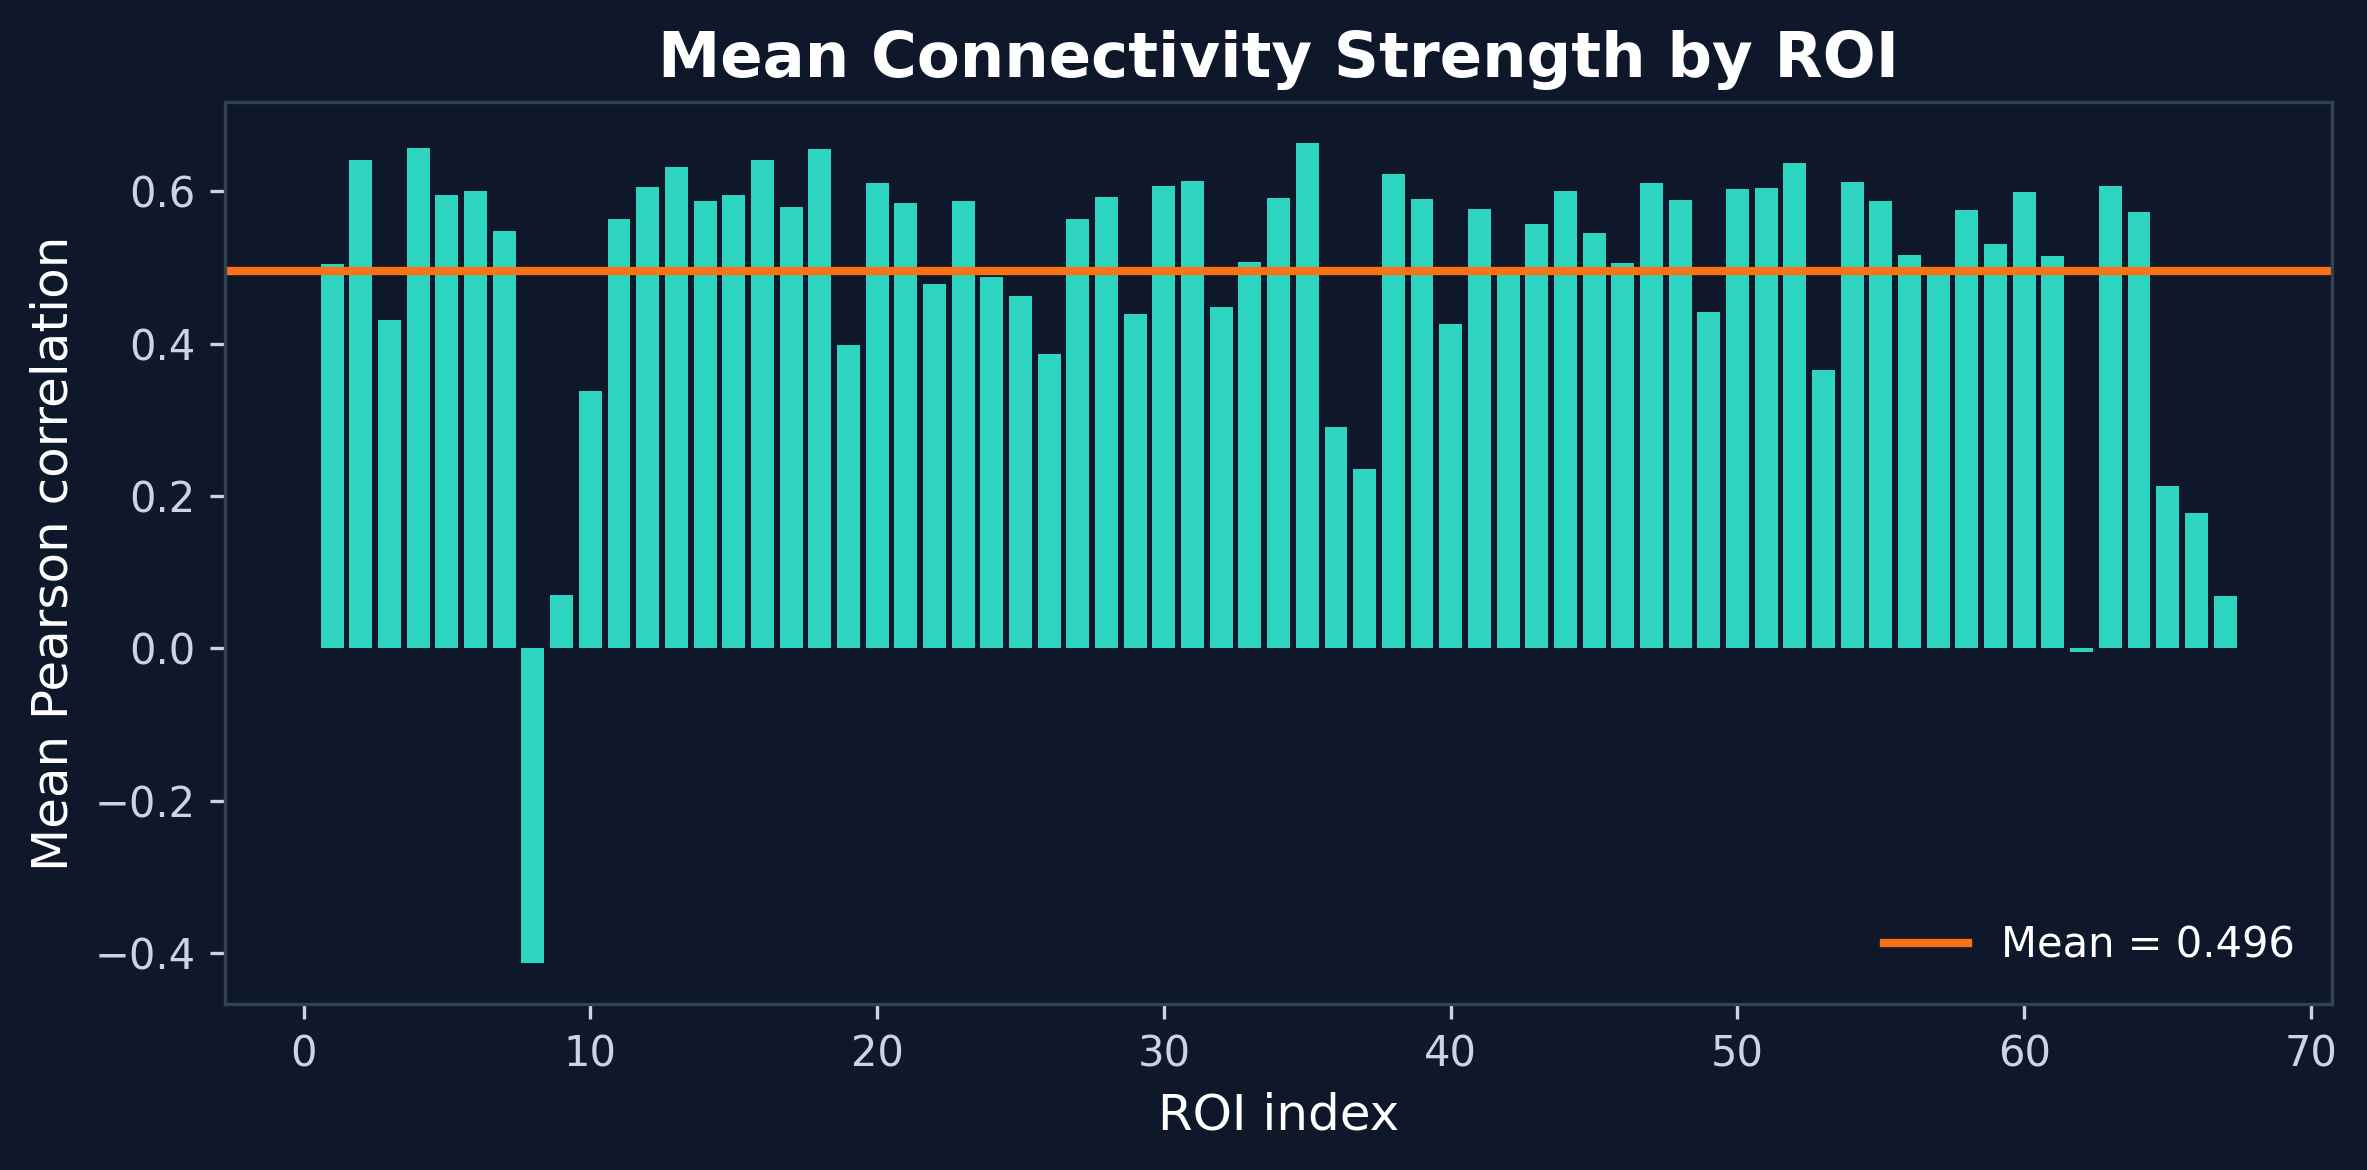

Saved: /content/node_strength_static_fc_dark.png


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fc_path = "/content/sub-PC001_ses-01_task-rest_run-1_static_fc.csv"
fc_df = pd.read_csv(fc_path, index_col=0)
fc = fc_df.values.astype(float)

# mask diagonal
fc_no_diag = fc.copy()
np.fill_diagonal(fc_no_diag, np.nan)

node_strength = np.nanmean(fc_no_diag, axis=1)

print("Node strength shape:", node_strength.shape)
print("Mean node strength:", np.mean(node_strength))
print("Max node strength ROI:", np.argmax(node_strength) + 1, np.max(node_strength))
print("Min node strength ROI:", np.argmin(node_strength) + 1, np.min(node_strength))

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

ax.bar(
    np.arange(1, len(node_strength) + 1),
    node_strength,
    color="#2dd4bf"
)

ax.axhline(np.mean(node_strength), color="#f97316", linewidth=2, label=f"Mean = {np.mean(node_strength):.3f}")

ax.set_title("Mean Connectivity Strength by ROI", fontsize=15, weight="bold", color="white")
ax.set_xlabel("ROI index", fontsize=12, color="white")
ax.set_ylabel("Mean Pearson correlation", fontsize=12, color="white")

ax.tick_params(colors="#cbd5e1")
ax.legend(frameon=False, labelcolor="white")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/node_strength_static_fc_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


In [27]:
from google.colab import files
uploaded = files.upload()

Saving fc_dfc.zip to fc_dfc.zip


In [28]:
import zipfile
import os

zip_path = "/content/fc_dfc.zip"
out_dir = "/content/fc_dfc"

os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(out_dir)

print("Extracted files:")
print(os.listdir(out_dir)[:10])

Extracted files:
['__MACOSX', 'fc_dfc']


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# === 1) set folder ===
# 如果你的 window files 在 /content/fc_dfc 裡，用這個
folder = Path("/content/fc_dfc")

# 如果你不確定位置，可以改成 Path("/content") 遞迴搜尋
window_files = sorted(folder.rglob("sub-PC001_ses-01_task-rest_run-1_window-*_fc_fisher_z.csv"))

print("Number of window files found:", len(window_files))

for f in window_files[:5]:
    print("Example file:", f.name)

if len(window_files) == 0:
    raise FileNotFoundError("No window files found. Check your folder path.")


Number of window files found: 45
Example file: sub-PC001_ses-01_task-rest_run-1_window-000_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-001_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-002_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-003_fc_fisher_z.csv
Example file: sub-PC001_ses-01_task-rest_run-1_window-004_fc_fisher_z.csv


In [30]:
def get_window_id(path):
    match = re.search(r"window-(\d+)", path.name)
    if match is None:
        raise ValueError(f"Cannot parse window id from {path.name}")
    return int(match.group(1))

window_files = sorted(window_files, key=get_window_id)
window_ids = np.array([get_window_id(f) for f in window_files])

print("Window IDs:", window_ids[:10], "...", window_ids[-5:])
print("Number of windows:", len(window_ids))


Window IDs: [0 1 2 3 4 5 6 7 8 9] ... [40 41 42 43 44]
Number of windows: 45


In [31]:
mats = []

for f in window_files:
    df = pd.read_csv(f, index_col=0)
    mat = df.values.astype(float)

    # basic check
    if mat.shape != (67, 67):
        raise ValueError(f"Unexpected shape {mat.shape} in {f.name}")

    # mask diagonal because Fisher z diagonal is artificially large
    np.fill_diagonal(mat, np.nan)

    mats.append(mat)

mats = np.stack(mats, axis=0)  # shape: windows x ROI x ROI

print("dFC array shape:", mats.shape)
print("Expected: number_of_windows x 67 x 67")
print("Min:", np.nanmin(mats))
print("Max:", np.nanmax(mats))


dFC array shape: (45, 67, 67)
Expected: number_of_windows x 67 x 67
Min: -1.487013801574164
Max: 2.92074843352411


Mean of window-level mean FC: 0.5054830249816703
SD of window-level mean FC: 0.1655302963321182
Min window mean FC: 0.13556253387646966
Max window mean FC: 0.8434206111162366


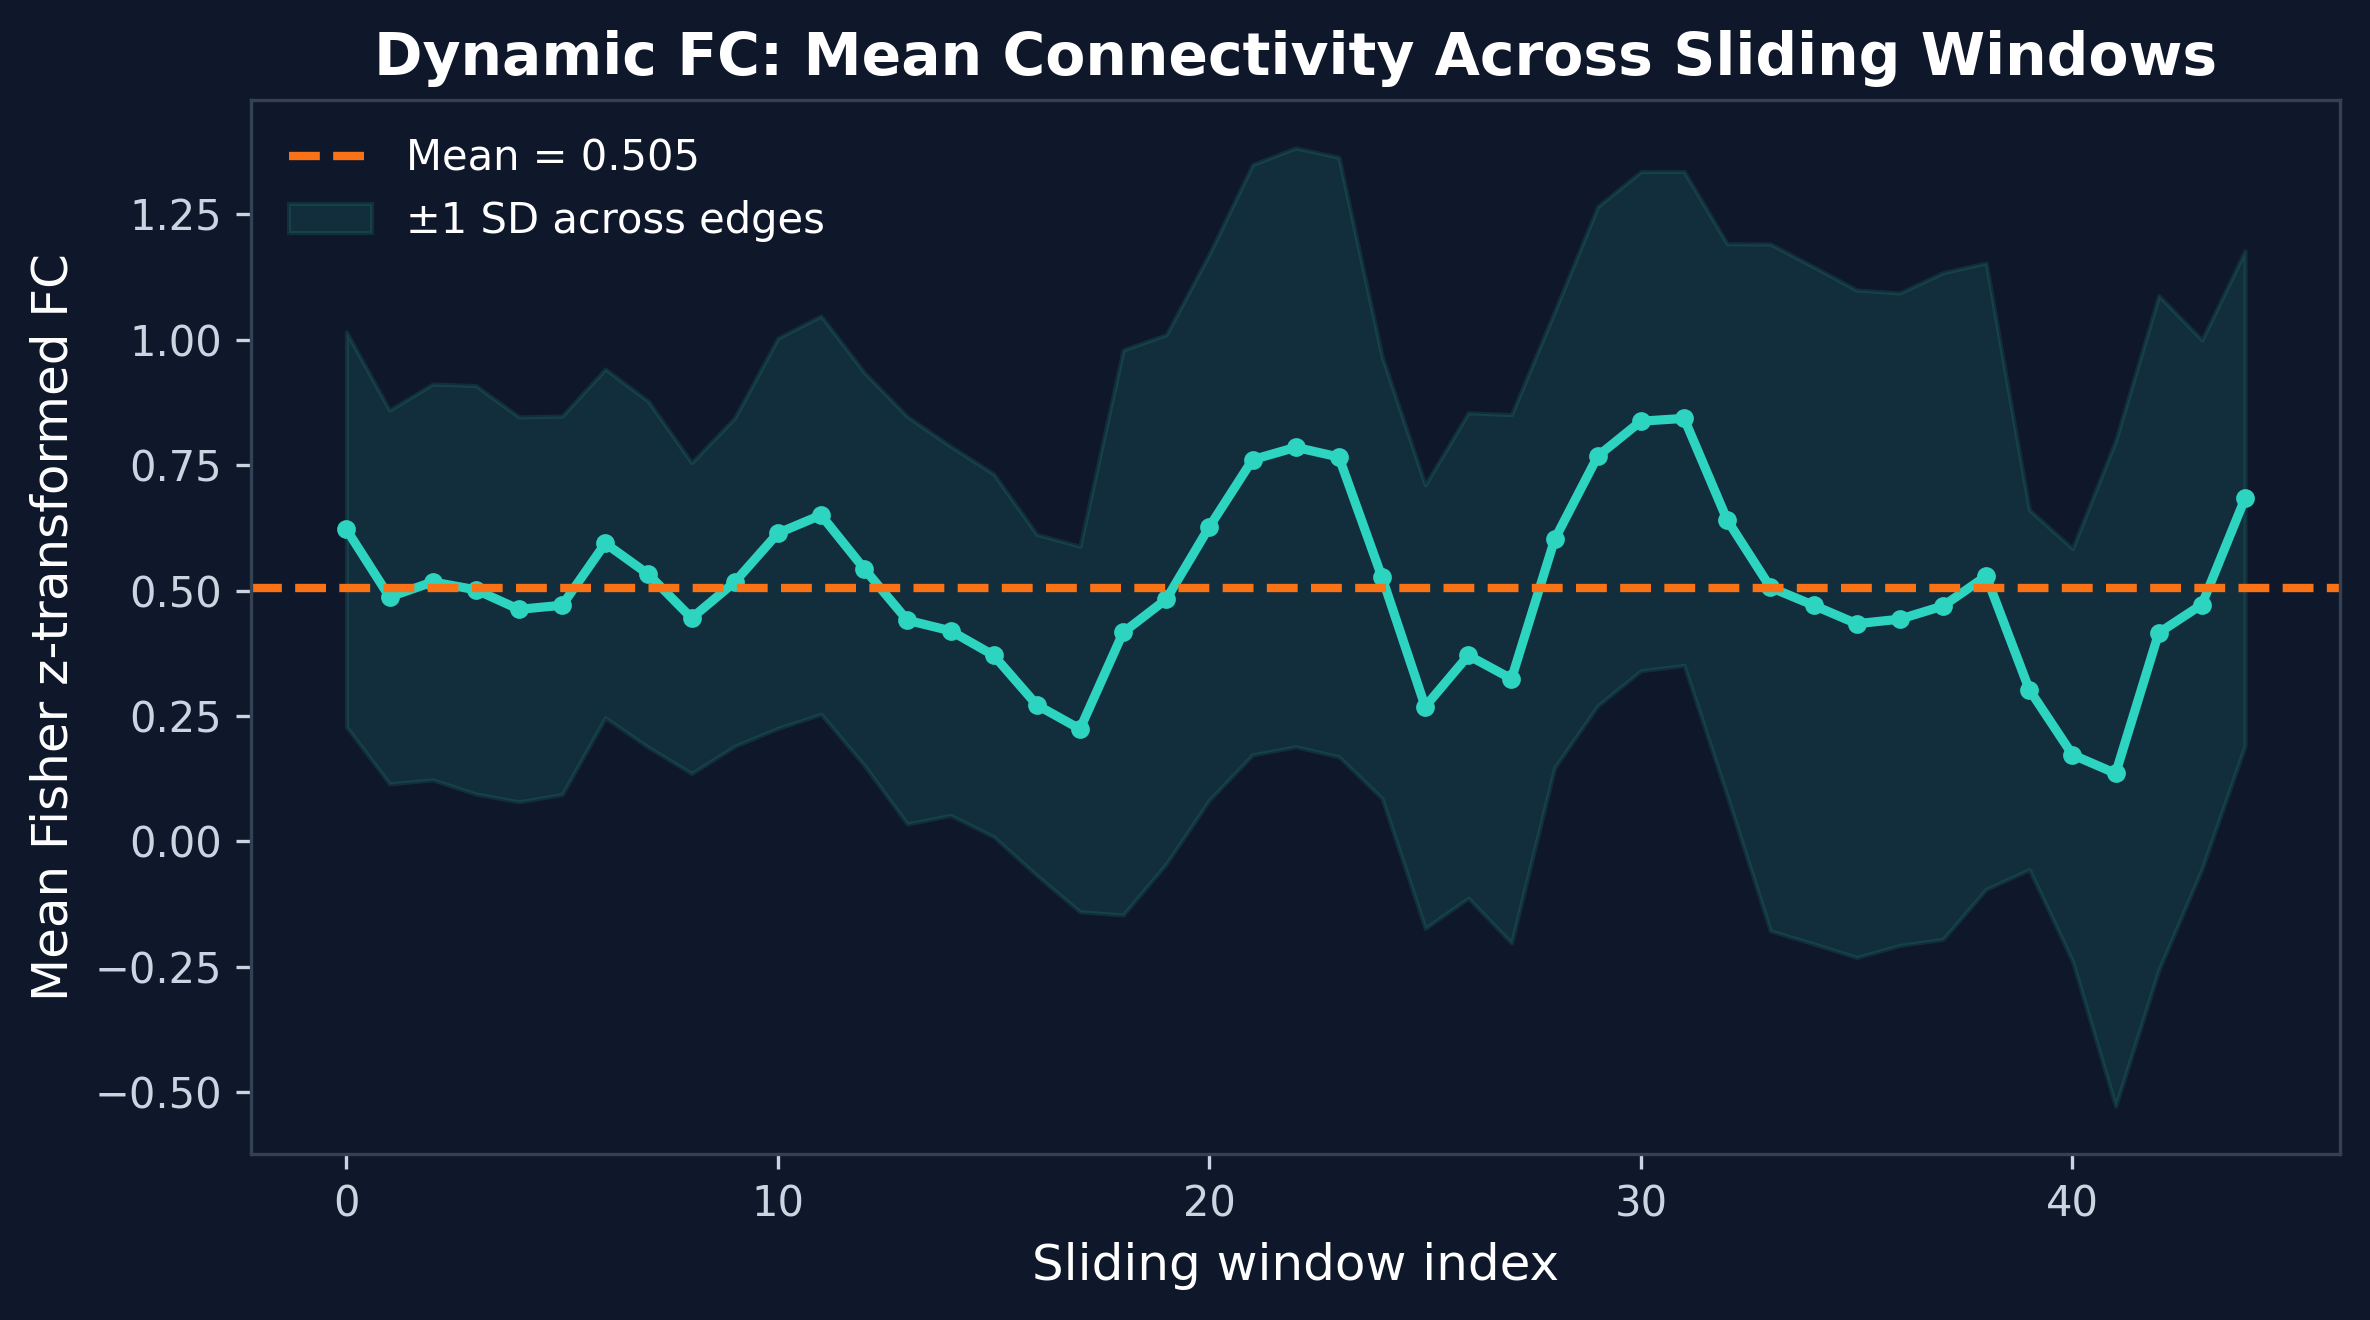

Saved: /content/dfc_mean_connectivity_timecourse_dark.png


In [32]:
# === compute mean and SD of edge values for each window ===
n_windows, n_roi, _ = mats.shape
upper_idx = np.triu_indices(n_roi, k=1)

mean_fc_per_window = []
sd_fc_per_window = []

for w in range(n_windows):
    edges = mats[w][upper_idx]
    mean_fc_per_window.append(np.nanmean(edges))
    sd_fc_per_window.append(np.nanstd(edges))

mean_fc_per_window = np.array(mean_fc_per_window)
sd_fc_per_window = np.array(sd_fc_per_window)

print("Mean of window-level mean FC:", np.mean(mean_fc_per_window))
print("SD of window-level mean FC:", np.std(mean_fc_per_window))
print("Min window mean FC:", np.min(mean_fc_per_window))
print("Max window mean FC:", np.max(mean_fc_per_window))

# === plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)

ax.plot(
    window_ids,
    mean_fc_per_window,
    color="#2dd4bf",
    linewidth=2.2,
    marker="o",
    markersize=3.5
)

ax.axhline(
    np.mean(mean_fc_per_window),
    color="#f97316",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(mean_fc_per_window):.3f}"
)

ax.fill_between(
    window_ids,
    mean_fc_per_window - sd_fc_per_window,
    mean_fc_per_window + sd_fc_per_window,
    color="#2dd4bf",
    alpha=0.12,
    label="±1 SD across edges"
)

ax.set_title("Dynamic FC: Mean Connectivity Across Sliding Windows", fontsize=14, weight="bold", color="white")
ax.set_xlabel("Sliding window index", fontsize=12, color="white")
ax.set_ylabel("Mean Fisher z-transformed FC", fontsize=12, color="white")

ax.tick_params(colors="#cbd5e1")
ax.legend(frameon=False, labelcolor="white")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/dfc_mean_connectivity_timecourse_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


dFC variability matrix shape: (67, 67)
Min variability: 0.12050818507459042
Max variability: 0.6527249362741745
Mean variability: 0.3606209564757253


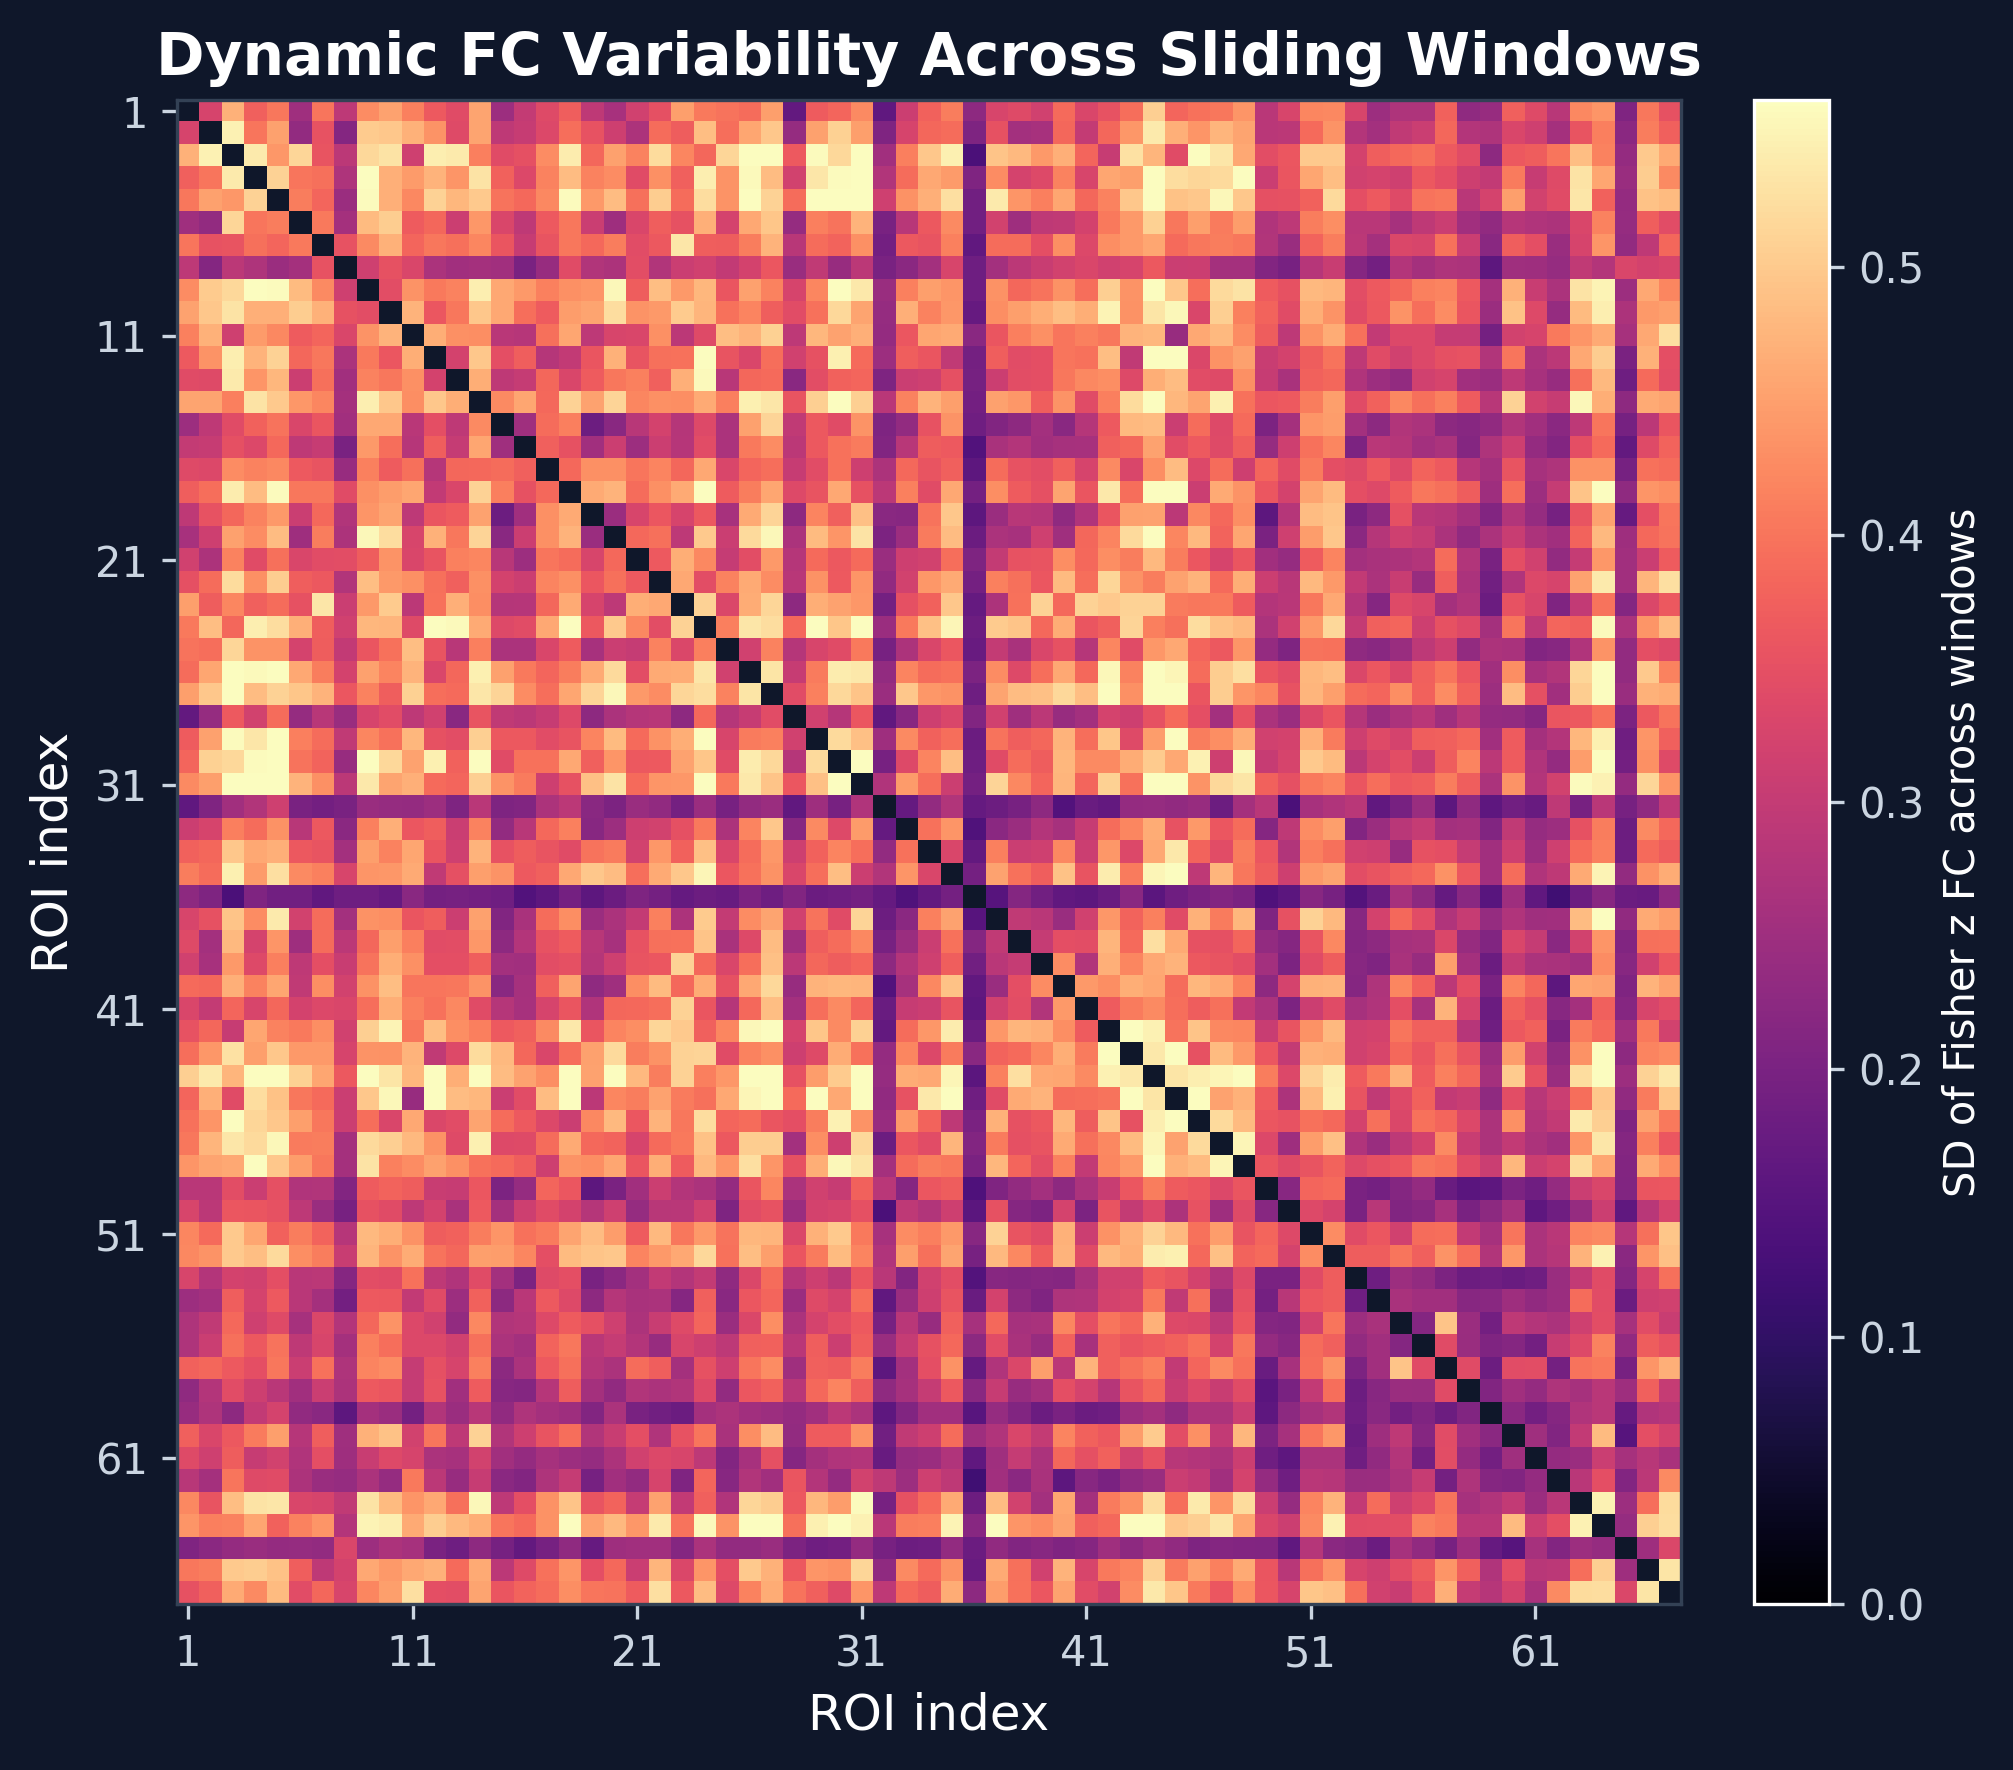

Saved: /content/dfc_variability_matrix_dark.png


In [33]:
# === compute temporal variability for each edge ===
dfc_var = np.nanstd(mats, axis=0)

# mask diagonal
np.fill_diagonal(dfc_var, np.nan)

print("dFC variability matrix shape:", dfc_var.shape)
print("Min variability:", np.nanmin(dfc_var))
print("Max variability:", np.nanmax(dfc_var))
print("Mean variability:", np.nanmean(dfc_var))

# robust color range
vmax = np.nanpercentile(dfc_var, 98)

# === plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

im = ax.imshow(
    dfc_var,
    cmap="magma",
    vmin=0,
    vmax=vmax,
    interpolation="nearest"
)

ax.set_title("Dynamic FC Variability Across Sliding Windows", fontsize=14, weight="bold", color="white")
ax.set_xlabel("ROI index", fontsize=12, color="white")
ax.set_ylabel("ROI index", fontsize=12, color="white")

tick_positions = np.arange(0, n_roi, 10)
tick_labels = np.arange(1, n_roi + 1, 10)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("SD of Fisher z FC across windows", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/dfc_variability_matrix_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)

Edge vector array shape: (45, 2211)
Window similarity shape: (45, 45)
Min: 0.11839103228557638
Max: 1.0


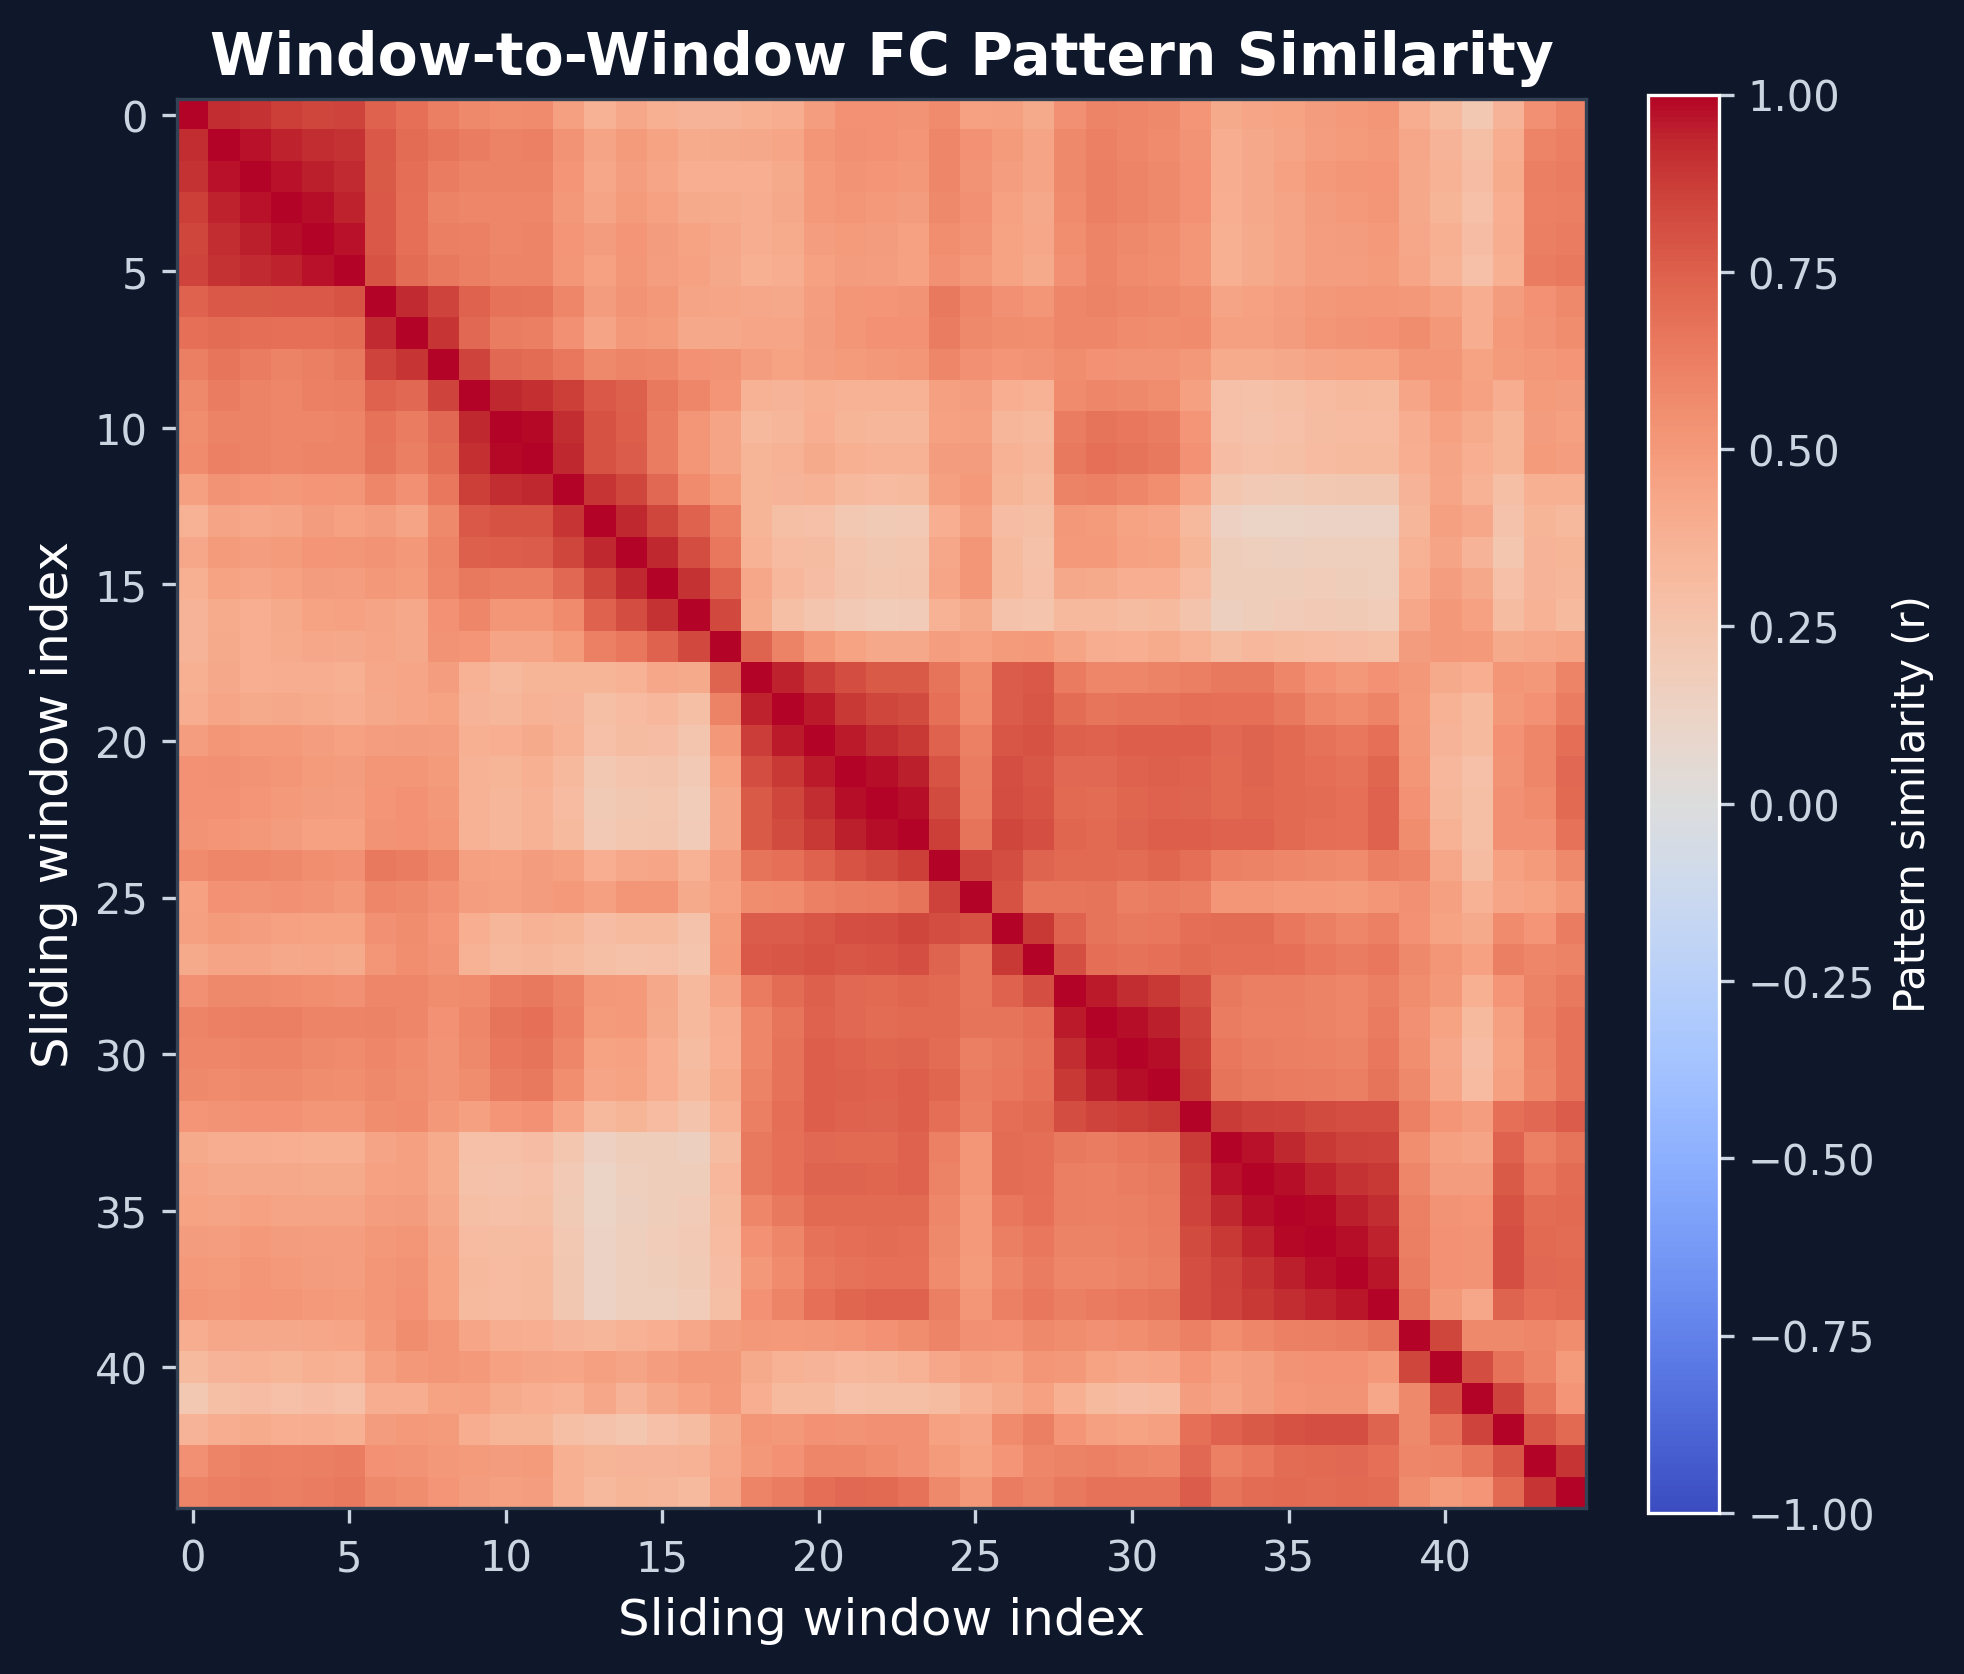

Saved: /content/window_to_window_fc_similarity_dark.png


In [34]:
# === vectorize each window's upper triangle ===
edge_vectors = []

for w in range(n_windows):
    edges = mats[w][upper_idx]
    edge_vectors.append(edges)

edge_vectors = np.array(edge_vectors)  # windows x edges

print("Edge vector array shape:", edge_vectors.shape)

# === compute window-to-window similarity ===
# correlation between window FC patterns
window_similarity = np.corrcoef(edge_vectors)

print("Window similarity shape:", window_similarity.shape)
print("Min:", np.nanmin(window_similarity))
print("Max:", np.nanmax(window_similarity))

# === plot ===
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(6.5, 5.8), dpi=300)

im = ax.imshow(
    window_similarity,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

ax.set_title("Window-to-Window FC Pattern Similarity", fontsize=14, weight="bold", color="white")
ax.set_xlabel("Sliding window index", fontsize=12, color="white")
ax.set_ylabel("Sliding window index", fontsize=12, color="white")

ax.tick_params(colors="#cbd5e1")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pattern similarity (r)", color="white")
cbar.ax.yaxis.set_tick_params(color="#cbd5e1")
plt.setp(cbar.ax.get_yticklabels(), color="#cbd5e1")

fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

for spine in ax.spines.values():
    spine.set_color("#334155")

out = "/content/window_to_window_fc_similarity_dark.png"
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved:", out)
